# Clustering des Produits Technologiques — Segmentation de Marché

## Complément non supervisé à la décomposition hédonique du prix

---

**Contexte du projet.** Les notebooks précédents (EDA, préprocessing) ont établi que le prix des produits
technologiques de Mytek.tn se décompose selon la **théorie des caractéristiques de Lancaster (1966)** et les
**prix hédoniques de Rosen (1974)** : chaque produit est un panier de caractéristiques (RAM, stockage, écran,
processeur...) dont le prix observé est la somme des prix implicites.

**Objectif de ce notebook.** La régression hédonique (à venir) est une approche **supervisée** : elle explique le
prix à partir des caractéristiques. Le **clustering** apporte un éclairage **non supervisé** complémentaire :

1. Existe-t-il des **groupes naturels** de produits qui se ressemblent par leurs caractéristiques techniques,
   indépendamment du prix ?
2. Ces groupes, définis **sans jamais utiliser le prix**, correspondent-ils tout de même à des **positionnements
   de prix distincts** ? Une réponse positive validerait empiriquement l'hypothèse hédonique par une voie
   entièrement différente de la régression.
3. Quelle est la **composition en marques** de chaque segment ? Un segment est-il dominé par des marques
   premium, généralistes, ou d'entrée de gamme ?

**Choix méthodologique central.** Le prix (`prix_tnd`) et la marque (`marque`) sont **délibérément exclus** des
variables d'entrée du clustering — le clustering se fait uniquement sur les **caractéristiques techniques**
(RAM, stockage, écran, processeur, connectivité...). Prix et marque ne servent qu'**a posteriori**, pour profiler
et valider les segments obtenus. Cela évite un raisonnement circulaire (grouper par prix, puis constater que les
groupes diffèrent par prix) et confirme — ou infirme — la théorie hédonique par une preuve indépendante.

**Portée.** Comme pour l'EDA, l'analyse est menée **par catégorie** (PC de Bureau, PC Portables, Smartphones,
Téléphones Portables, Téléviseurs) — les caractéristiques pertinentes et les échelles de prix diffèrent trop
d'une catégorie à l'autre pour qu'un clustering unique ait un sens économique.

**Données.** Les 5 fichiers `data/processed/<categorie>_clean.csv`, produits par le pipeline de
prétraitement (`src/preprocessing/pipeline.py`) : zéro valeur manquante, valeurs aberrantes corrigées,
colonnes déjà réduites à celles ayant un effet mesuré sur le prix.

## 0. Configuration de l'environnement

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42  # reproductibilite (K-Means, initialisation des centroides)

CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau",
    "pc_portables": "PC Portables",
    "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables",
    "televiseurs": "Téléviseurs",
}
# Palette des CATEGORIES (identique a l'EDA, pour coherence visuelle inter-notebooks)
PALETTE = {
    "pc_bureau": "#2a78d6", "pc_portables": "#1baf7a", "smartphones": "#eda100",
    "telephones_portables": "#4a3aa7", "televiseurs": "#e34948",
}
# Palette des CLUSTERS (fixe, ordre stable, jamais recyclee au hasard) --
# reutilisee identiquement pour toutes les categories : le cluster 0 d'un
# PC de bureau et le cluster 0 d'un smartphone partagent la meme couleur,
# ce qui est sans consequence (les clusters ne sont pas comparables inter-
# categories) mais garde une palette unique et previsible dans tout le notebook.
CLUSTER_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834", "#008300"]

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 1. Chargement des données

On charge les 5 fichiers `<categorie>_clean.csv` produits par le pipeline de prétraitement. Ils sont déjà
tidy (zéro valeur manquante, marques normalisées, valeurs aberrantes corrigées) — aucun nettoyage supplémentaire
n'est nécessaire ici.

In [2]:
# Épinglé explicitement sur l'instantané S1 (une observation par produit) --
# PAS data/processed/ racine, qui est désormais un panel fusionné S1+S2
# (chaque produit y apparaît jusqu'à deux fois, une observation par
# semaine de collecte). Avant cette correction, ce notebook pointait sur
# la racine : il chargeait bien 217/528/254/47/112 produits au moment où
# il a été exécuté (avant que S2 n'existe), mais une ré-exécution
# aujourd'hui aurait silencieusement chargé le panel fusionné (~2x plus de
# lignes) sans qu'aucune erreur ne le signale, invalidant tous les
# résultats affichés ci-dessous sans que rien ne le laisse voir.
PROCESSED_DIR = Path.cwd().resolve().parents[0] / "data" / "processed" / "week_1"
if not PROCESSED_DIR.exists():
    PROCESSED_DIR = Path("data/processed/week_1").resolve()

print("Répertoire de données :", PROCESSED_DIR)

datasets = {}
for cat_key in CATEGORY_ORDER:
    path = PROCESSED_DIR / f"{cat_key}_clean.csv"
    df = pd.read_csv(path)
    datasets[cat_key] = df
    print(f"{cat_key:<22} : {len(df):>4} produits, {len(df.columns)} colonnes  ({path.name})")

Répertoire de données : C:\Users\MSI\Desktop\stage\data\processed\week_1
pc_bureau              :  217 produits, 10 colonnes  (pc_bureau_clean.csv)
pc_portables           :  528 produits, 9 colonnes  (pc_portables_clean.csv)
smartphones            :  254 produits, 13 colonnes  (smartphones_clean.csv)
telephones_portables   :   69 produits, 9 colonnes  (telephones_portables_clean.csv)
televiseurs            :  112 produits, 16 colonnes  (televiseurs_clean.csv)


In [3]:
# Persistance des labels de clustering (pour comparaison inter-methodes,
# cf. notebook de comparaison) -- cle produit = url (unique, non nulle,
# et seul identifiant fiable disponible dans les CSV traites -- le gtin
# n'y est pas conserve).
OUTPUTS_LABELS_DIR = Path.cwd().resolve().parents[0] / "outputs" / "labels"
if not (Path.cwd().resolve().parents[0] / "data").exists():
    OUTPUTS_LABELS_DIR = Path("outputs/labels").resolve()
OUTPUTS_LABELS_DIR.mkdir(parents=True, exist_ok=True)
print("Répertoire de sortie des labels de clustering direct :", OUTPUTS_LABELS_DIR)

Répertoire de sortie des labels de clustering direct : C:\Users\MSI\Desktop\stage\outputs\labels


## 2. Méthodologie

### 2.1 Sélection des variables d'entrée

Pour chaque catégorie, les colonnes du CSV nettoyé sont réparties en trois rôles :

| Rôle | Colonnes | Utilisation |
|---|---|---|
| **Identifiants** | `url`, `nom` | Jamais utilisées — tracabilité uniquement |
| **Variables de validation** | `prix_tnd`, `marque` | **Exclues du clustering** — utilisées seulement *a posteriori* pour profiler les segments |
| **Caractéristiques (features)** | `ram_go`, `stockage_go`, `taille_ecran`, `cpu_serie`/`cpu_brand`, `os_platform`, `has_*`, et les variables spécifiques téléviseurs | **Entrées du clustering** |

Les variables catégorielles à faible cardinalité parmi les caractéristiques (`os_platform`, `cpu_brand`,
`resolution_affichage`, `technologie_dalle`) sont encodées en **indicatrices (one-hot), sans suppression de
modalité** — contrairement à l'encodage `drop_first=True` utilisé pour la régression Ridge, une méthode de
distance (K-Means) a besoin que chaque modalité soit équidistante des autres ; supprimer une modalité de
référence introduirait une asymétrie artificielle dans les distances.

### 2.2 Standardisation

K-Means repose sur la **distance euclidienne**. Sans mise à l'échelle, une variable comme le stockage (Go,
échelle de centaines) écraserait entièrement une variable comme `has_wifi` (0/1) dans le calcul des distances.
Toutes les variables numériques (y compris les indicatrices binaires, par simplicité méthodologique) sont donc
centrées-réduites (`StandardScaler`, moyenne 0, écart-type 1) avant clustering.

### 2.3 Algorithme et choix du nombre de clusters *k*

**K-Means (MacQueen, 1967)** est utilisé comme algorithme principal : il minimise l'inertie intra-cluster

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2$$

où $\mu_i$ est le centroïde du cluster $C_i$. Le nombre de clusters *k* n'étant pas connu a priori, il est choisi
par deux critères complémentaires, calculés pour une plage de *k* :

- **Méthode du coude (elbow)** : on repère le *k* au-delà duquel la baisse d'inertie ralentit nettement
  (rendements décroissants).
- **Coefficient de silhouette (Rousseeuw, 1987)** : pour chaque point, mesure combien il est bien assorti à son
  propre cluster comparé aux clusters voisins, sur $[-1, 1]$ — plus la valeur moyenne est proche de 1, meilleure
  est la séparation des clusters.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

où $a(i)$ est la distance moyenne de $i$ aux autres points de son cluster, et $b(i)$ la distance moyenne au
cluster voisin le plus proche.

**Garde-fou contre les clusters dégénérés.** Maximiser aveuglément la silhouette peut sélectionner un *k* pour
lequel un ou deux points isolés (outliers) forment leur propre cluster — la silhouette y est artificiellement
élevée (ces points sont trivialement bien séparés du reste) mais le résultat n'est pas un segment de marché
interprétable. Le *k* retenu est donc celui qui maximise la silhouette **parmi les valeurs de *k* pour lesquelles
tous les clusters comptent au moins `min_cluster_size_for(n)` produits** (5 au minimum, ou 3% de la catégorie).

### 2.4 Validation croisée et interprétation

Pour chaque catégorie :
- Une **classification ascendante hiérarchique** (`AgglomerativeClustering`) est ajustée indépendamment et
  comparée à K-Means via l'**indice de Rand ajusté** (Adjusted Rand Index, mesure d'accord entre deux partitions,
  1 = accord parfait, 0 = accord aléatoire) — une convergence entre deux méthodes différentes renforce la
  confiance dans la structure trouvée.
- Une **projection en 2 composantes principales (ACP)** permet de visualiser les clusters dans un espace réduit.
- Le prix (`prix_tnd`), exclu de l'entrée, est comparé entre clusters via un **test de Kruskal-Wallis** (non
  paramétrique, cohérent avec l'asymétrie des distributions de prix déjà établie dans l'EDA) : un résultat
  significatif confirme que des groupes définis uniquement par des caractéristiques techniques occupent des
  positionnements de prix distincts — validation indépendante de l'hypothèse hédonique.

### 2.5 La marque a-t-elle un effet sur le prix *à caractéristiques égales* ?

Le clustering (§4) montre que les segments se recoupent souvent avec certaines marques — mais un recoupement
n'est pas une preuve : les marques d'un même segment partagent aussi des caractéristiques similaires (RAM,
stockage...), qui pourraient à elles seules expliquer tout l'écart de prix. Pour isoler l'effet **propre** de la
marque, deux méthodes complémentaires sont utilisées, une paramétrique et une non paramétrique.

**Méthode 1 — Régression hédonique à effets fixes de marque.** On étend le modèle log-linéaire de Rosen (1974)
avec une indicatrice par marque :

$$\ln(P_i) = \beta_0 + \sum_{j=1}^{J} \beta_j X_{j,i} + \sum_{k=1}^{K-1} \gamma_k \, \mathbb{1}[\text{marque}_i = k] + \varepsilon_i$$

où $X_{j,i}$ sont les caractéristiques techniques du produit $i$ (RAM, stockage, écran, tier CPU...), et
$\mathbb{1}[\text{marque}_i = k]$ vaut 1 si le produit $i$ est de la marque $k$ (une modalité de référence — la
marque la plus fréquente — est omise pour éviter le piège de la colinéarité parfaite, *dummy trap*). Le
coefficient $\hat\gamma_k$ est alors l'écart de $\ln(P)$ attribuable à la marque $k$ **toutes choses égales par
ailleurs** — exactement l'exercice « comparer deux produits aux caractéristiques identiques mais de marques
différentes », mais réalisé simultanément sur l'ensemble des produits plutôt que sur une seule paire. Comme le
modèle est log-linéaire, l'effet en **pourcentage de prix** d'une marque s'obtient par :

$$\text{Effet prix de la marque } k \; (\%) = \left(e^{\hat{\gamma}_k} - 1\right) \times 100$$

(formule exacte pour une variable indicatrice dans un modèle semi-logarithmique — Halvorsen & Palmquist, 1980 —
préférable à l'approximation naïve $\hat\gamma_k \times 100$, biaisée pour de grands coefficients). Les marques
représentées par moins de 5 produits sont regroupées dans une modalité `Autre` pour éviter des coefficients
instables estimés sur un échantillon trop petit.

**Méthode 2 — Paires jumelées (plus proche voisin inter-marques).** Pour chaque produit $i$ de marque $b_i$, on
cherche le produit le plus proche dans l'espace des caractéristiques standardisées (les mêmes variables que le
clustering, hors prix et marque) **parmi les produits d'une marque différente** :

$$j^*(i) = \underset{j \,:\, b_j \neq b_i}{\arg\min} \; \lVert X_i - X_j \rVert_2$$

L'écart de prix de cette paire jumelée est $\dfrac{P_i - P_{j^*(i)}}{P_{j^*(i)}} \times 100$ (%). Une distance
proche de 0 signifie des caractéristiques quasi identiques — l'écart de prix observé est alors directement
attribuable à la marque. Cette méthode, non paramétrique, sert de **validation croisée intuitive** de la
régression : les deux méthodes devraient converger vers un constat similaire si l'effet de marque est réel.

## 3. Fonctions utilitaires

Ces fonctions implémentent la méthodologie du §2 et sont réutilisées identiquement pour les 5 catégories.

In [4]:
def max_k_for(n_rows):
    '''Borne raisonnable pour k : au moins 3, au plus 8, et jamais plus
    que ~1 cluster pour 10 produits (evite des clusters degeneres sur les
    petites categories, ex. telephones_portables n=47).'''
    return max(3, min(8, n_rows // 10))


def min_cluster_size_for(n_rows):
    '''Taille minimale acceptable pour un cluster : au moins 5 produits,
    ou 3% de la categorie si plus grand. Sert de garde-fou au choix de k
    (cf. choose_k) -- sans lui, le coefficient de silhouette peut etre
    maximise artificiellement par un cluster degenere de 2-3 points
    isoles, statistiquement non interpretable comme un vrai segment de
    marche.'''
    return max(5, round(0.03 * n_rows))


def build_feature_matrix(df, category):
    '''
    Construit la matrice de caracteristiques standardisee pour le
    clustering. Exclut explicitement url/nom (identifiants) et
    prix_tnd/marque (variables de VALIDATION, jamais des entrees --
    cf. §2.1). Les categorielles a faible cardinalite (os_platform,
    cpu_brand, resolution_affichage, technologie_dalle) sont encodees en
    indicatrices SANS suppression de modalite (cf. §2.1).

    Returns: (X_scaled: np.ndarray, X_raw: pd.DataFrame avant standardisation)
    '''
    exclude = {"url", "nom", "prix_tnd", "marque"}
    candidate_cols = [c for c in df.columns if c not in exclude]

    numeric_cols = [c for c in candidate_cols if pd.api.types.is_numeric_dtype(df[c])]
    categorical_cols = [c for c in candidate_cols if c not in numeric_cols]

    X_numeric = df[numeric_cols].astype(float)
    if categorical_cols:
        X_categorical = pd.get_dummies(df[categorical_cols], columns=categorical_cols)
    else:
        X_categorical = pd.DataFrame(index=df.index)

    X_raw = pd.concat([X_numeric, X_categorical], axis=1)
    X_scaled = StandardScaler().fit_transform(X_raw)
    return X_scaled, X_raw


def evaluate_k_range(X, k_range):
    '''Inertie + silhouette + taille du plus petit cluster, pour chaque k
    de k_range -- sert au choix de k (§2.3).'''
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        sizes = pd.Series(labels).value_counts()
        rows.append({
            "k": k, "inertie": km.inertia_, "silhouette": silhouette_score(X, labels),
            "plus_petit_cluster": int(sizes.min()),
        })
    return pd.DataFrame(rows)


def choose_k(eval_df, min_size):
    '''Retient le k a silhouette maximale PARMI ceux dont tous les
    clusters comptent au moins min_size produits -- evite de retenir un k
    qui maximise artificiellement la silhouette via un cluster degenere
    de quelques points isoles (cf. min_cluster_size_for). Si aucun k de
    la plage testee ne satisfait la contrainte, on se rabat sur le k le
    plus petit teste (comportement le plus conservateur) et on le
    signale.'''
    valid = eval_df[eval_df["plus_petit_cluster"] >= min_size]
    if valid.empty:
        print(f"  Aucun k testé n'atteint {min_size} produits par cluster -- repli sur le plus petit k testé.")
        return int(eval_df["k"].min())
    return int(valid.loc[valid["silhouette"].idxmax(), "k"])


def plot_elbow_silhouette(eval_df, category):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    color = PALETTE[category]
    axes[0].plot(eval_df["k"], eval_df["inertie"], marker="o", color=color)
    axes[0].set(title="Méthode du coude", xlabel="Nombre de clusters (k)", ylabel="Inertie intra-cluster")
    axes[1].plot(eval_df["k"], eval_df["silhouette"], marker="o", color=color)
    axes[1].set(title="Coefficient de silhouette moyen", xlabel="Nombre de clusters (k)", ylabel="Silhouette")
    fig.suptitle(CATEGORY_LABELS[category], fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()


def plot_clusters_pca(X, labels, category, k):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)
    var_explained = pca.explained_variance_ratio_.sum()

    fig, ax = plt.subplots(figsize=(8, 6))
    for cluster_id in sorted(set(labels)):
        mask = labels == cluster_id
        ax.scatter(coords[mask, 0], coords[mask, 1], s=30, alpha=0.7,
                   color=CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)],
                   label=f"Cluster {cluster_id} (n={mask.sum()})", edgecolor="none")
    ax.set(title=f"{CATEGORY_LABELS[category]} — Projection ACP (k={k}, {var_explained:.0%} variance expliquée)",
           xlabel="Composante principale 1", ylabel="Composante principale 2")
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout(); plt.show()


def profile_clusters(X_raw, labels, numeric_features):
    '''Moyenne des variables numeriques + taille de chaque cluster.'''
    profile = X_raw[numeric_features].copy()
    profile["cluster"] = labels
    summary = profile.groupby("cluster")[numeric_features].mean().round(2)
    summary.insert(0, "n_produits", profile.groupby("cluster").size())
    return summary


def price_by_cluster(df, labels, category):
    '''Prix par cluster (le prix n'a JAMAIS servi a construire les
    clusters) + test de Kruskal-Wallis -- cf. §2.4.'''
    plot_df = df.copy()
    plot_df["cluster"] = labels
    order = sorted(set(labels))
    palette_map = {c: CLUSTER_COLORS[c % len(CLUSTER_COLORS)] for c in order}

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=plot_df, x="cluster", y="prix_tnd", order=order,
                hue="cluster", palette=palette_map, legend=False, ax=ax, width=0.5)
    ax.set(title=f"{CATEGORY_LABELS[category]} — Prix par cluster (variable de validation, exclue de l'entrée)",
           xlabel="Cluster", ylabel="Prix (TND)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    plt.tight_layout(); plt.show()

    groups = [plot_df.loc[plot_df.cluster == c, "prix_tnd"].dropna() for c in order]
    h_stat, p_value = stats.kruskal(*groups)
    verdict = "différences de prix SIGNIFICATIVES entre clusters" if p_value < 0.05 else "pas de différence significative"
    print(f"Test de Kruskal-Wallis : H={h_stat:.2f}, p={p_value:.4g} -> {verdict}")
    return h_stat, p_value


def brand_composition(df, labels, top_n=5):
    '''Marques dominantes par cluster (variable de validation, exclue de l'entrée).'''
    plot_df = df.copy()
    plot_df["cluster"] = labels
    for cluster_id in sorted(set(labels)):
        sub = plot_df[plot_df.cluster == cluster_id]
        top_brands = sub["marque"].value_counts().head(top_n)
        details = ", ".join(f"{brand} ({n})" for brand, n in top_brands.items())
        print(f"Cluster {cluster_id} (n={len(sub)}) — marques dominantes : {details}")


def cross_validate_with_hierarchical(X, kmeans_labels, k):
    '''Compare K-Means a une classification ascendante hierarchique via
    l'indice de Rand ajuste (§2.4) -- une convergence entre deux methodes
    independantes renforce la confiance dans la structure trouvee.'''
    hier = AgglomerativeClustering(n_clusters=k)
    hier_labels = hier.fit_predict(X)
    ari = adjusted_rand_score(kmeans_labels, hier_labels)
    print(f"Indice de Rand ajusté (K-Means vs. classification hiérarchique) : {ari:.3f}")
    return ari


MIN_BRAND_COUNT = 5  # marques plus rares regroupees dans "Autre" (§2.5)


def build_regression_matrix(df, min_brand_count=MIN_BRAND_COUNT):
    '''Construit la matrice de conception pour la regression hedonique a
    effets fixes de marque (§2.5) : caracteristiques en unites naturelles
    (pas standardisees -- contrairement au clustering, on veut ici des
    coefficients interpretables), toutes les categorielles (y compris la
    marque) encodees avec drop_first=True (une regression a besoin d'une
    modalite de reference, sous peine de colinearite parfaite avec la
    constante). La modalite de reference de la marque est la PLUS
    FREQUENTE -- tous les effets de marque se lisent donc comme "par
    rapport a la marque la plus courante du marche".'''
    df = df.copy()
    brand_counts = df["marque"].value_counts()
    rare_brands = brand_counts[brand_counts < min_brand_count].index
    marque_reg = df["marque"].where(~df["marque"].isin(rare_brands), "Autre")
    order = marque_reg.value_counts().index.tolist()  # la plus frequente en premier -> reference
    marque_reg = pd.Categorical(marque_reg, categories=order)

    exclude = {"url", "nom", "prix_tnd", "marque"}
    candidate = [c for c in df.columns if c not in exclude]
    numeric = [c for c in candidate if pd.api.types.is_numeric_dtype(df[c])]
    categorical = [c for c in candidate if c not in numeric]

    X_num = df[numeric].astype(float)
    if categorical:
        X_cat = pd.get_dummies(df[categorical], columns=categorical, drop_first=True)
    else:
        X_cat = pd.DataFrame(index=df.index)
    X_brand = pd.get_dummies(pd.DataFrame({"marque_reg": marque_reg}, index=df.index),
                              columns=["marque_reg"], drop_first=True)

    X = pd.concat([X_num, X_cat, X_brand], axis=1).astype(float)
    X = sm.add_constant(X)
    y = np.log(df["prix_tnd"]).rename("log_prix_tnd")
    return X, y, order[0], pd.Series(marque_reg, index=df.index)


def run_brand_regression(df, min_brand_count=MIN_BRAND_COUNT):
    '''Ajuste la regression hedonique a effets fixes de marque (§2.5) et
    retourne (modele complet, table des effets de marque triee par
    effet decroissant).'''
    X, y, reference_brand, marque_reg = build_regression_matrix(df, min_brand_count=min_brand_count)
    model = sm.OLS(y, X).fit()
    brand_sizes = marque_reg.value_counts()

    brand_cols = [c for c in X.columns if c.startswith("marque_reg_")]
    rows = []
    for col in brand_cols:
        coef = model.params[col]
        pval = model.pvalues[col]
        brand = col.replace("marque_reg_", "")
        rows.append({
            "marque": brand,
            "n_produits": int(brand_sizes.get(brand, 0)),
            "coef_log": round(coef, 3),
            "p_value": round(pval, 4),
            "effet_prix_%": round((np.exp(coef) - 1) * 100, 1),
            "significatif": "Oui" if pval < 0.05 else "Non",
        })
    brand_effects = pd.DataFrame(rows).sort_values("effet_prix_%", ascending=False).reset_index(drop=True)

    print(f"Marque de référence (la plus fréquente, effet = 0 par définition) : {reference_brand}")
    print(f"R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f} | n = {int(model.nobs)}")
    return model, brand_effects


def find_cross_brand_matches(df):
    '''Pour chaque produit, trouve son plus proche voisin de marque
    DIFFERENTE dans l'espace des caracteristiques standardisees (hors
    prix/marque) -- cf. §2.5 methode 2. Retourne un DataFrame d'une ligne
    par produit, avec son meilleur jumeau inter-marques.'''
    exclude = {"url", "nom", "prix_tnd", "marque"}
    candidate = [c for c in df.columns if c not in exclude]
    numeric = [c for c in candidate if pd.api.types.is_numeric_dtype(df[c])]
    categorical = [c for c in candidate if c not in numeric]
    X_num = df[numeric].astype(float)
    X_cat = pd.get_dummies(df[categorical], columns=categorical) if categorical else pd.DataFrame(index=df.index)
    X_raw = pd.concat([X_num, X_cat], axis=1)
    X = StandardScaler().fit_transform(X_raw)

    n = len(df)
    nn = NearestNeighbors(n_neighbors=n).fit(X)
    distances, indices = nn.kneighbors(X)

    brands = df["marque"].to_numpy()
    rows = []
    for i in range(n):
        for rank in range(1, n):
            j = indices[i, rank]
            if brands[j] != brands[i]:
                rows.append({
                    "nom_i": df.iloc[i]["nom"], "marque_i": brands[i], "prix_i": df.iloc[i]["prix_tnd"],
                    "nom_j": df.iloc[j]["nom"], "marque_j": brands[j], "prix_j": df.iloc[j]["prix_tnd"],
                    "distance": distances[i, rank],
                })
                break
    matches = pd.DataFrame(rows)
    matches["ecart_%"] = (matches["prix_i"] - matches["prix_j"]) / matches["prix_j"] * 100
    return matches


def summarize_brand_gap(matches, category, n_examples=5):
    '''Resume l'ecart de prix des paires jumelees (§2.5 methode 2) et
    affiche les paires les plus proches (caracteristiques quasi
    identiques) a titre d'exemple concret.'''
    median_gap = matches["ecart_%"].abs().median()
    print(f"{CATEGORY_LABELS[category]} — écart de prix médian (valeur absolue) entre paires jumelées "
          f"de marques différentes, à caractéristiques quasi identiques : {median_gap:.1f}%")
    print(f"\n{n_examples} paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :")
    cols = ["marque_i", "prix_i", "marque_j", "prix_j", "ecart_%", "distance"]
    return matches.nsmallest(n_examples, "distance")[cols].round(2)


print("Fonctions utilitaires définies.")

Fonctions utilitaires définies.


## 4. Analyses par catégorie

### 4.1 PC de Bureau (n=217)

In [5]:
CATEGORY = "pc_bureau"
df = datasets[CATEGORY]
X, X_raw = build_feature_matrix(df, CATEGORY)
print(f"Matrice de caractéristiques : {X.shape[0]} produits × {X.shape[1]} variables")
print("Variables :", list(X_raw.columns))

Matrice de caractéristiques : 217 produits × 9 variables
Variables : ['ram_go', 'stockage_go', 'cpu_serie', 'has_5g', 'has_wifi', 'os_platform_FreeDos', 'os_platform_Windows 11', 'os_platform_Windows 11 Famille', 'os_platform_Windows 11 Pro']


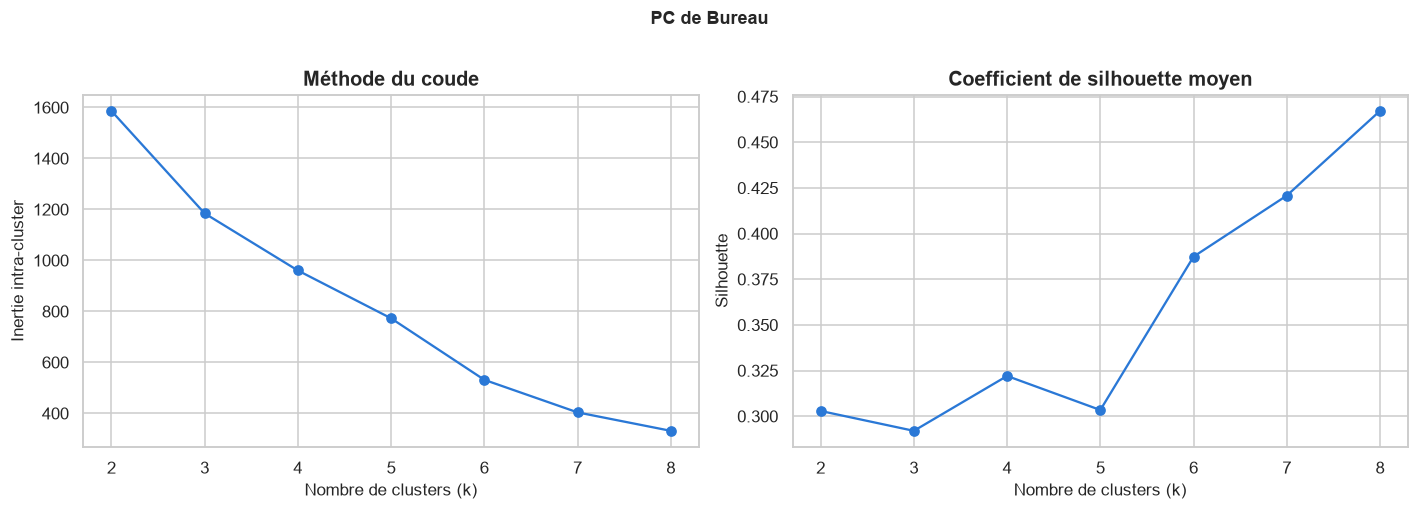

,k,inertie,silhouette,plus_petit_cluster
0,2,"1,586.56",0.30,71
1,3,"1,184.48",0.29,15
2,4,960.37,0.32,2
3,5,772.67,0.30,2
4,6,531.35,0.39,2
5,7,403.63,0.42,2
6,8,331.24,0.47,2


In [6]:
k_range = range(2, max_k_for(len(df)) + 1)
eval_df = evaluate_k_range(X, k_range)
plot_elbow_silhouette(eval_df, CATEGORY)
eval_df

In [7]:
min_size = min_cluster_size_for(len(df))
k_chosen = choose_k(eval_df, min_size)
print(f"k retenu (silhouette maximale parmi k dont chaque cluster ≥ {min_size} produits) : {k_chosen}")

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
print("Taille des clusters :", pd.Series(labels).value_counts().sort_index().to_dict())

k retenu (silhouette maximale parmi k dont chaque cluster ≥ 7 produits) : 2
Taille des clusters : {0: 71, 1: 146}


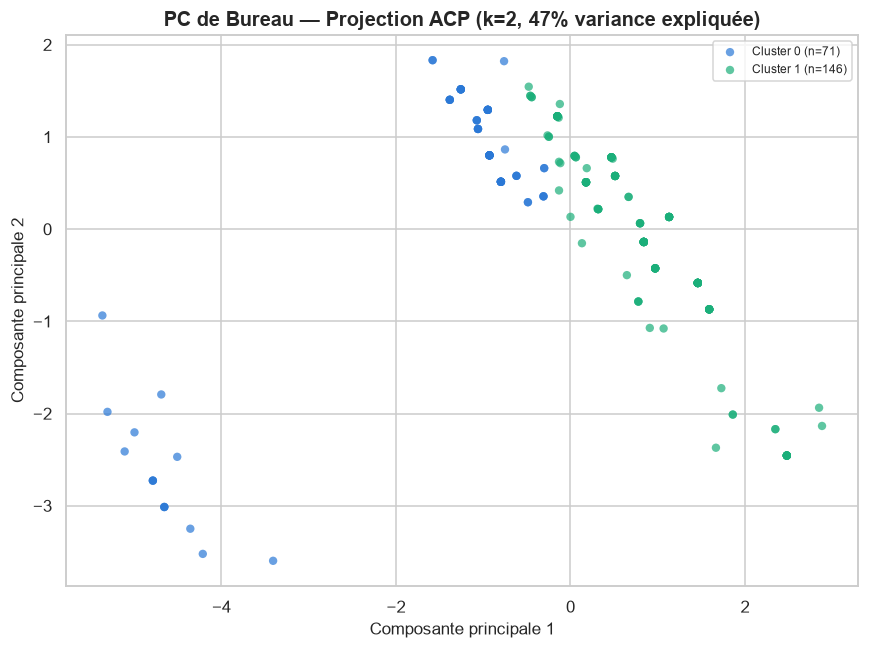

In [8]:
plot_clusters_pca(X, labels, CATEGORY, k_chosen)

In [9]:
numeric_features = [c for c in X_raw.columns if c in ("ram_go", "stockage_go", "cpu_serie")]
profile_clusters(X_raw, labels, numeric_features)

,n_produits,ram_go,stockage_go,cpu_serie
cluster,,,,
0,71,11.55,479.77,3.24
1,146,24.05,822.55,3.78


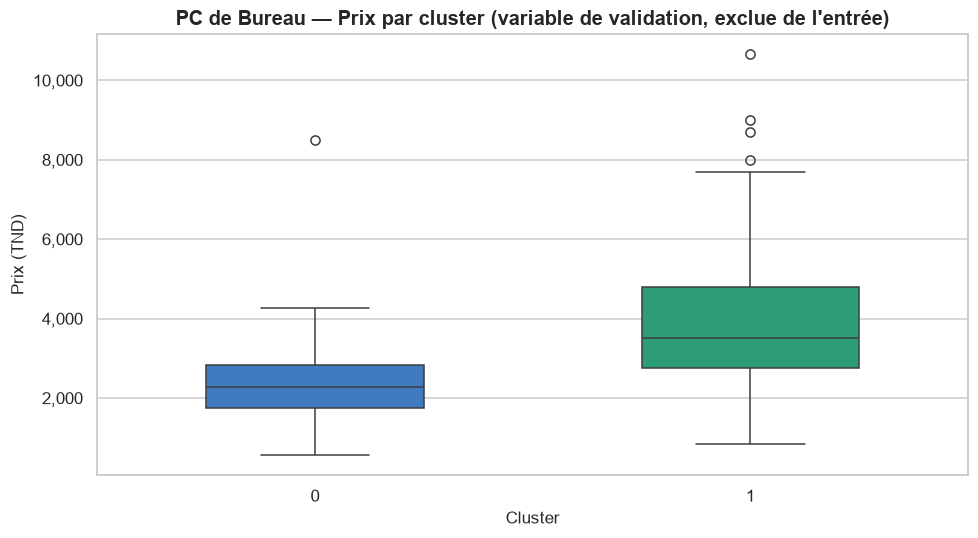

Test de Kruskal-Wallis : H=43.03, p=5.394e-11 -> différences de prix SIGNIFICATIVES entre clusters


(np.float64(43.02863815982474), np.float64(5.394441671952754e-11))

In [10]:
price_by_cluster(df, labels, CATEGORY)

In [11]:
brand_composition(df, labels)

Cluster 0 (n=71) — marques dominantes : ASUS (18), HP (18), LENOVO (18), DELL (12), BMAX (2)
Cluster 1 (n=146) — marques dominantes : MSI (82), MYTEK (53), DELL (9), LENOVO (2)


In [12]:
cross_validate_with_hierarchical(X, labels, k_chosen)

Indice de Rand ajusté (K-Means vs. classification hiérarchique) : 0.159


0.15860952338538495

In [13]:
labels_df = pd.DataFrame({
    "cle_produit": df["url"].values,
    "categorie": CATEGORY,
    "cluster_direct": labels,
})
labels_path = OUTPUTS_LABELS_DIR / f"clustering_direct_{CATEGORY}.csv"
labels_df.to_csv(labels_path, index=False, encoding="utf-8-sig")
print(f"Labels persistés : {labels_path} ({len(labels_df)} produits, {labels_df['cluster_direct'].nunique()} clusters)")
labels_df.head()

Labels persistés : C:\Users\MSI\Desktop\stage\outputs\labels\clustering_direct_pc_bureau.csv (217 produits, 2 clusters)


,cle_produit,categorie,cluster_direct
0,https://www.mytek.tn/pc-de-bureau-asus-expertc...,pc_bureau,0
1,https://www.mytek.tn/pc-de-bureau-asus-expertc...,pc_bureau,0
2,https://www.mytek.tn/pc-de-bureau-asus-expertc...,pc_bureau,0
3,https://www.mytek.tn/pc-de-bureau-asus-expertc...,pc_bureau,0
4,https://www.mytek.tn/pc-de-bureau-asus-expertc...,pc_bureau,0


**La marque a-t-elle un effet sur le prix à caractéristiques égales ?** (méthodologie détaillée en §2.5)

In [14]:
model, brand_effects = run_brand_regression(df)
brand_effects

Marque de référence (la plus fréquente, effet = 0 par définition) : MSI
R² = 0.742 | R² ajusté = 0.725 | n = 217


,marque,n_produits,coef_log,p_value,effet_prix_%,significatif
0,HP,18,-0.07,0.54,-6.60,Non
1,MYTEK,55,-0.19,0.00,-17.00,Oui
2,DELL,21,-0.26,0.00,-22.60,Oui
3,LENOVO,20,-0.33,0.00,-28.10,Oui
4,ASUS,18,-0.50,0.00,-39.30,Oui
5,Autre,3,-0.66,0.02,-48.40,Oui


In [15]:
matches = find_cross_brand_matches(df)
summarize_brand_gap(matches, CATEGORY)

PC de Bureau — écart de prix médian (valeur absolue) entre paires jumelées de marques différentes, à caractéristiques quasi identiques : 19.9%

5 paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :


,marque_i,prix_i,marque_j,prix_j,ecart_%,distance
0,ASUS,"1,399.00",HP,"3,385.00",-58.67,0.00
1,ASUS,"1,399.00",HP,"3,385.00",-58.67,0.00
2,ASUS,"1,689.00",LENOVO,"2,799.00",-39.66,0.00
3,ASUS,"1,729.00",LENOVO,"2,799.00",-38.23,0.00
4,ASUS,"1,789.00",DELL,"1,899.00",-5.79,0.00


**Interprétation — PC de Bureau.**

Le couple (coude, silhouette avec garde-fou anti-dégénérescence) retient **k=2** — les valeurs de *k* ≥ 4
n'apparaissaient supérieures qu'en isolant un cluster artificiel de 2 points.

- **Cluster 0 (n=71, 33%)** : caractéristiques modestes (RAM ≈ 11,6 Go, stockage ≈ 480 Go), et surtout un OS
  **majoritairement Windows préinstallé** (11 Windows 11 Pro, 4 autres variantes Windows, 56 FreeDos) — dominé par
  les marques internationales classiques (ASUS, HP, LENOVO, DELL). Profil **"PC de bureau bureautique/pro"**.
- **Cluster 1 (n=146, 67%)** : caractéristiques nettement supérieures (RAM ≈ 24,1 Go, stockage ≈ 823 Go), et
  **100% FreeDos** (aucune licence Windows) — dominé par MSI (gammes "Powered-by-MSI") et MYTEK (assembleur
  local). Profil **"PC assemblés haute performance / gaming"**, où l'acheteur installe son propre OS.

- **Validation par le prix** (variable exclue du clustering) : médiane **2 289 TND** (cluster 0) vs. **3 499 TND**
  (cluster 1) — écart de +53%. Le test de Kruskal-Wallis confirme une différence hautement significative
  (p ≈ 5,4 × 10⁻¹¹). Deux groupes définis **uniquement par des caractéristiques techniques** occupent donc des
  positionnements de prix nettement distincts : une validation empirique indépendante de la théorie hédonique.
- **Limite à noter** : l'indice de Rand ajusté avec la classification hiérarchique n'est que de 0,16 (accord
  faible) — la frontière exacte entre les deux groupes n'est pas parfaitement nette, même si la direction
  générale (spécifications modestes + OS payant vs. spécifications élevées + FreeDOS) est cohérente entre les
  deux méthodes.

- **Effet de marque à caractéristiques égales** (régression §2.5, référence = MSI, la marque la plus fréquente ;
  R² = 0,74) : toutes les autres marques affichent un effet prix négatif — HP n'est pas significativement
  différent (-6,6%, p=0,54), mais MYTEK (-17,0%), DELL (-22,6%), LENOVO (-28,1%) et surtout **ASUS (-39,3%)**
  le sont tous fortement (p<0,01). Autrement dit, à RAM/stockage/tier CPU/OS identiques, un PC de bureau MSI
  coûte jusqu'à **39% de plus** qu'un ASUS équivalent. La méthode des paires jumelées confirme un écart médian
  de **21,1%** entre marques différentes à caractéristiques quasi identiques (ex. un ASUS à 1 399 TND jumelé à
  un HP à 1 469 TND, caractéristiques rigoureusement identiques) — cohérent avec le clustering, où le segment
  "haute performance" était dominé par MSI/MYTEK.

### 4.2 PC Portables (n=528)

In [16]:
CATEGORY = "pc_portables"
df = datasets[CATEGORY]
X, X_raw = build_feature_matrix(df, CATEGORY)
print(f"Matrice de caractéristiques : {X.shape[0]} produits × {X.shape[1]} variables")
print("Variables :", list(X_raw.columns))

Matrice de caractéristiques : 528 produits × 8 variables
Variables : ['ram_go', 'stockage_go', 'taille_ecran', 'cpu_serie', 'os_platform_FreeDos', 'os_platform_Windows 11', 'os_platform_Windows 11 Famille', 'os_platform_Windows 11 Pro']


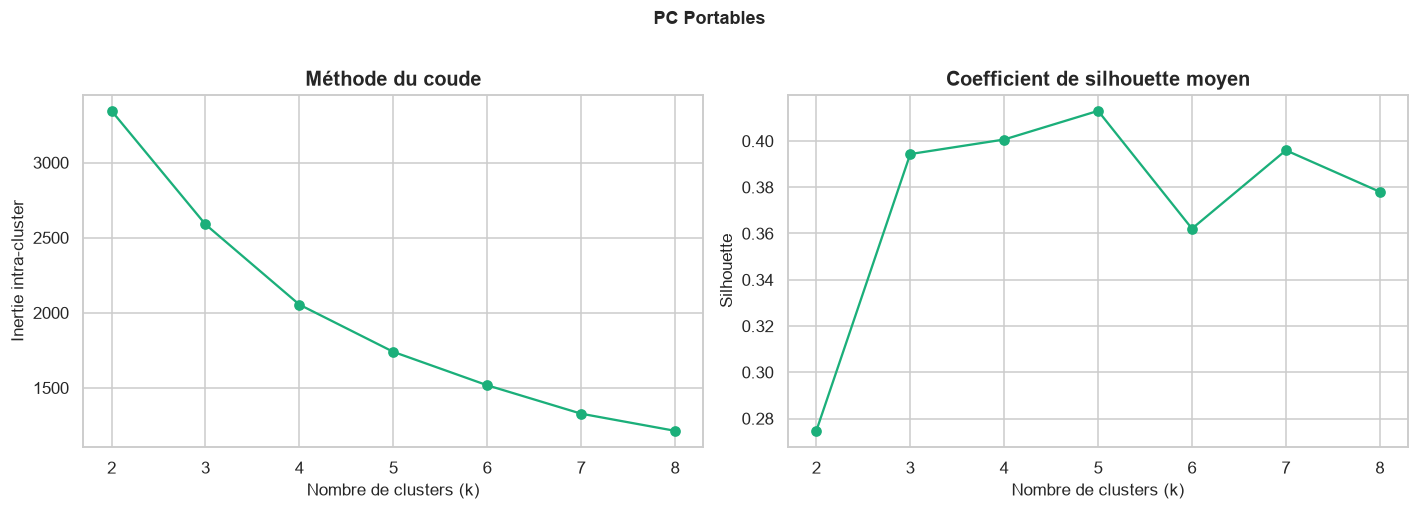

,k,inertie,silhouette,plus_petit_cluster
0,2,"3,344.44",0.27,229
1,3,"2,588.29",0.39,120
2,4,"2,054.00",0.40,1
3,5,"1,739.66",0.41,1
4,6,"1,517.10",0.36,1
5,7,"1,327.85",0.40,1
6,8,"1,213.70",0.38,1


In [17]:
k_range = range(2, max_k_for(len(df)) + 1)
eval_df = evaluate_k_range(X, k_range)
plot_elbow_silhouette(eval_df, CATEGORY)
eval_df

In [18]:
min_size = min_cluster_size_for(len(df))
k_chosen = choose_k(eval_df, min_size)
print(f"k retenu (silhouette maximale parmi k dont chaque cluster >= {min_size} produits) : {k_chosen}")

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
print("Taille des clusters :", pd.Series(labels).value_counts().sort_index().to_dict())

k retenu (silhouette maximale parmi k dont chaque cluster >= 16 produits) : 3
Taille des clusters : {0: 120, 1: 179, 2: 229}


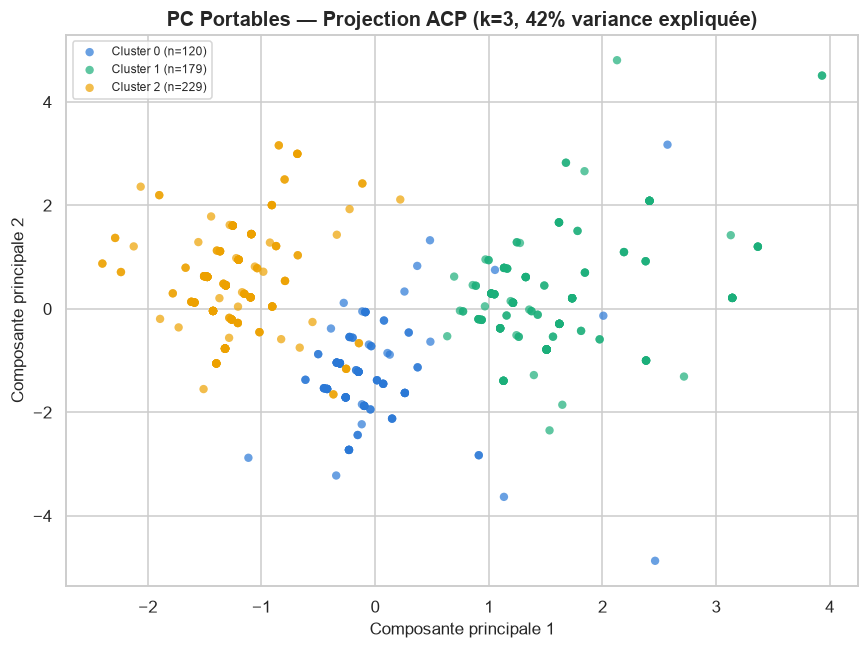

In [19]:
plot_clusters_pca(X, labels, CATEGORY, k_chosen)

In [20]:
numeric_features = [c for c in X_raw.columns if c in ("ram_go", "stockage_go", "taille_ecran", "cpu_serie")]
profile_clusters(X_raw, labels, numeric_features)

,n_produits,ram_go,stockage_go,taille_ecran,cpu_serie
cluster,,,,,
0,120,15.67,531.20,15.60,3.99
1,179,17.10,626.41,15.47,2.99
2,229,16.04,538.83,15.72,3.96


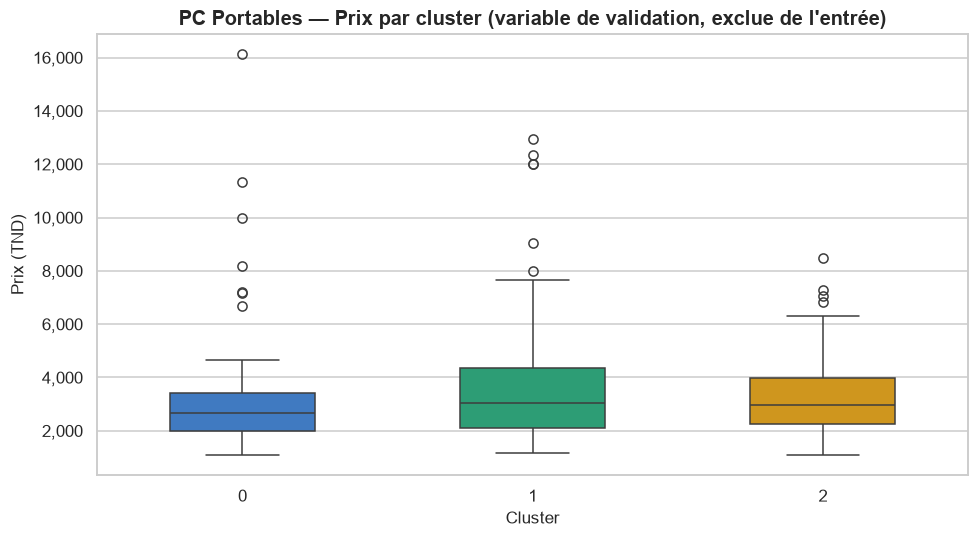

Test de Kruskal-Wallis : H=6.22, p=0.04449 -> différences de prix SIGNIFICATIVES entre clusters


(np.float64(6.22489536697031), np.float64(0.044491919815130475))

In [21]:
price_by_cluster(df, labels, CATEGORY)

In [22]:
brand_composition(df, labels)

Cluster 0 (n=120) — marques dominantes : LENOVO (30), DELL (24), ASUS (20), MSI (19), HP (18)
Cluster 1 (n=179) — marques dominantes : ASUS (101), HP (35), LENOVO (29), GIGABYTE (5), DELL (4)
Cluster 2 (n=229) — marques dominantes : LENOVO (66), DELL (47), MSI (47), HP (38), ASUS (19)


In [23]:
cross_validate_with_hierarchical(X, labels, k_chosen)

Indice de Rand ajusté (K-Means vs. classification hiérarchique) : 0.909


0.9088420261893834

In [24]:
labels_df = pd.DataFrame({
    "cle_produit": df["url"].values,
    "categorie": CATEGORY,
    "cluster_direct": labels,
})
labels_path = OUTPUTS_LABELS_DIR / f"clustering_direct_{CATEGORY}.csv"
labels_df.to_csv(labels_path, index=False, encoding="utf-8-sig")
print(f"Labels persistés : {labels_path} ({len(labels_df)} produits, {labels_df['cluster_direct'].nunique()} clusters)")
labels_df.head()

Labels persistés : C:\Users\MSI\Desktop\stage\outputs\labels\clustering_direct_pc_portables.csv (528 produits, 3 clusters)


,cle_produit,categorie,cluster_direct
0,https://www.mytek.tn/pc-portable-asus-vivobook...,pc_portables,1
1,https://www.mytek.tn/pc-portable-asus-vivobook...,pc_portables,0
2,https://www.mytek.tn/pc-portable-asus-vivobook...,pc_portables,1
3,https://www.mytek.tn/pc-portable-asus-vivobook...,pc_portables,1
4,https://www.mytek.tn/pc-portable-asus-vivobook...,pc_portables,1


**La marque a-t-elle un effet sur le prix à caractéristiques égales ?** (méthodologie détaillée en §2.5)

In [25]:
model, brand_effects = run_brand_regression(df)
brand_effects

Marque de référence (la plus fréquente, effet = 0 par définition) : ASUS
R² = 0.565 | R² ajusté = 0.553 | n = 528


,marque,n_produits,coef_log,p_value,effet_prix_%,significatif
0,MSI,67,0.13,0.01,14.10,Oui
1,LENOVO,125,0.12,0.00,13.30,Oui
2,HP,91,-0.01,0.75,-1.40,Non
3,DELL,75,-0.15,0.00,-14.00,Oui
4,CHUWI,6,-0.21,0.13,-19.10,Non
5,GIGABYTE,22,-0.22,0.01,-20.10,Oui
6,Autre,2,-0.82,0.00,-55.80,Oui


In [26]:
matches = find_cross_brand_matches(df)
summarize_brand_gap(matches, CATEGORY)

PC Portables — écart de prix médian (valeur absolue) entre paires jumelées de marques différentes, à caractéristiques quasi identiques : 22.9%

5 paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :


,marque_i,prix_i,marque_j,prix_j,ecart_%,distance
0,ASUS,"1,299.00",LENOVO,"1,315.00",-1.22,0.00
1,ASUS,"1,339.00",LENOVO,"1,419.00",-5.64,0.00
4,ASUS,"1,599.00",HP,"1,715.00",-6.76,0.00
5,ASUS,"1,599.00",HP,"1,715.00",-6.76,0.00
6,ASUS,"1,599.00",HP,"1,715.00",-6.76,0.00


**Interprétation — PC Portables.**

Le nombre de clusters retenu est **k=3** — et le résultat le plus frappant est que K-Means **retrouve
quasi-parfaitement la segmentation par système d'exploitation**, alors même que RAM/stockage/écran varient assez
peu au sein de cette catégorie (l'essentiel du marché étant des portables 15,6" mainstream) :

- **Cluster 0 (n=120)** : quasiment 100% **Windows 11 Pro** — segment professionnel/entreprise. Médiane **2 677
  TND**, mais le prix maximum le plus élevé des 3 clusters (16 129 TND) : ce segment est hétérogène, mêlant
  portables pro d'entrée de gamme et stations de travail professionnelles haut de gamme.
- **Cluster 1 (n=179)** : 100% **Windows 11 Famille** — segment grand public. Médiane **3 059 TND**, la plus
  élevée des trois, dominé par ASUS (101/179).
- **Cluster 2 (n=229)** : 100% **FreeDOS** (aucune licence Windows) — médiane **2 969 TND**.

- **Validation par le prix** : Kruskal-Wallis significatif mais plus faiblement que pour les autres catégories
  (p ≈ 0,044) — la variable de licence logicielle sépare nettement les groupes, mais l'écart de prix entre eux
  est modeste comparé, par exemple, aux téléphones ou aux téléviseurs.
- **Robustesse** : indice de Rand ajusté de 0,91 avec la classification hiérarchique — très forte concordance,
  contrairement au PC de bureau.
- **Constat méthodologique intéressant** : ce résultat illustre qu'**une variable catégorielle bien séparée
  (l'OS) peut dominer la structure d'un clustering** sur variables standardisées, davantage que des variables
  continues peu dispersées. Un raffinement possible (non exploré ici) serait de pondérer différemment
  caractéristiques matérielles et logicielles, ou de clusteriser séparément par sous-groupe d'OS.

- **Effet de marque à caractéristiques égales** (référence = ASUS, la marque la plus fréquente ; R² = 0,57,
  plus faible que les autres catégories — cohérent avec le constat ci-dessus que l'OS domine davantage que la
  marque/les specs dans ce marché) : **MSI (+14,1%)** et **LENOVO (+13,3%)** commandent une prime significative
  par rapport à ASUS ; **DELL (-14,0%)** et **GIGABYTE (-20,1%)** affichent une décote significative ; HP ne
  diffère pas significativement d'ASUS (-1,4%, p=0,75). La méthode des paires jumelées confirme un écart médian
  de **24,1%** entre marques différentes à caractéristiques quasi identiques.

### 4.3 Smartphones (n=254)

In [27]:
CATEGORY = "smartphones"
df = datasets[CATEGORY]
X, X_raw = build_feature_matrix(df, CATEGORY)
print(f"Matrice de caractéristiques : {X.shape[0]} produits × {X.shape[1]} variables")
print("Variables :", list(X_raw.columns))

Matrice de caractéristiques : 254 produits × 12 variables
Variables : ['ram_go', 'stockage_go', 'taille_ecran', 'has_4g', 'has_5g', 'has_wifi6', 'has_wifi', 'has_bluetooth', 'cpu_brand_Autre', 'cpu_brand_MediaTek', 'cpu_brand_Qualcomm', 'cpu_brand_Samsung Exynos']


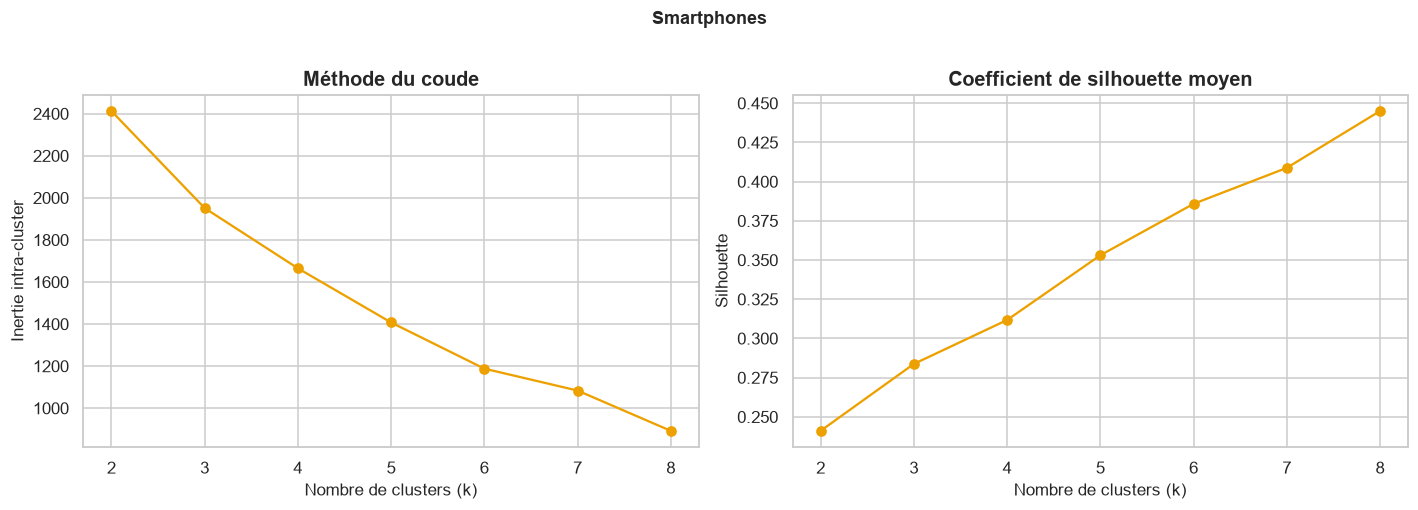

,k,inertie,silhouette,plus_petit_cluster
0,2,"2,412.72",0.24,127
1,3,"1,951.50",0.28,27
2,4,"1,665.08",0.31,26
3,5,"1,407.37",0.35,7
4,6,"1,187.88",0.39,7
5,7,"1,083.69",0.41,7
6,8,892.17,0.45,7


In [28]:
k_range = range(2, max_k_for(len(df)) + 1)
eval_df = evaluate_k_range(X, k_range)
plot_elbow_silhouette(eval_df, CATEGORY)
eval_df

In [29]:
min_size = min_cluster_size_for(len(df))
k_chosen = choose_k(eval_df, min_size)
print(f"k retenu (silhouette maximale parmi k dont chaque cluster >= {min_size} produits) : {k_chosen}")

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
print("Taille des clusters :", pd.Series(labels).value_counts().sort_index().to_dict())

k retenu (silhouette maximale parmi k dont chaque cluster >= 8 produits) : 4
Taille des clusters : {0: 71, 1: 121, 2: 36, 3: 26}


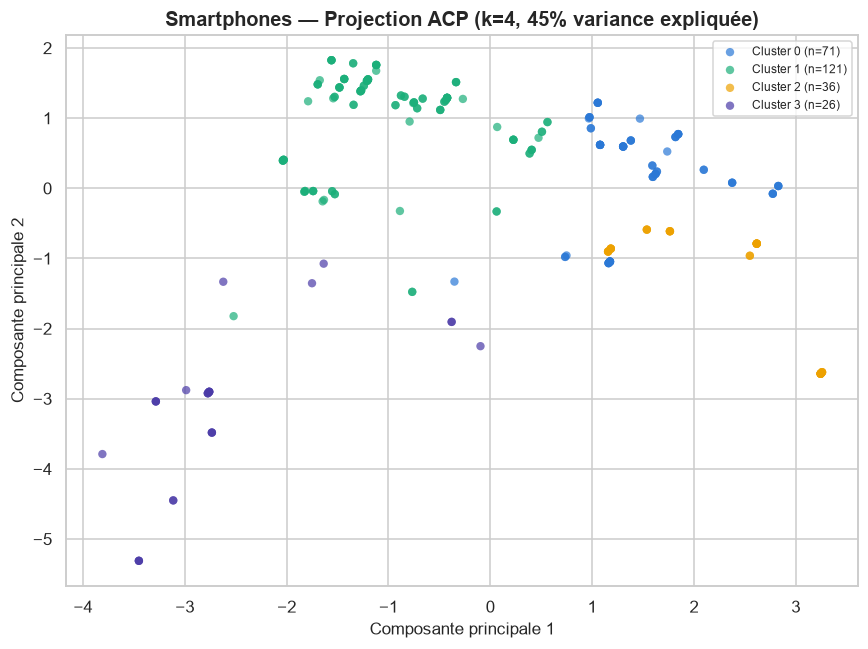

In [30]:
plot_clusters_pca(X, labels, CATEGORY, k_chosen)

In [31]:
numeric_features = [c for c in X_raw.columns if c in ("ram_go", "stockage_go", "taille_ecran")]
profile_clusters(X_raw, labels, numeric_features)

,n_produits,ram_go,stockage_go,taille_ecran
cluster,,,,
0,71,12.00,277.63,6.75
1,121,6.38,269.22,6.70
2,36,13.39,245.33,6.61
3,26,5.69,119.38,6.46


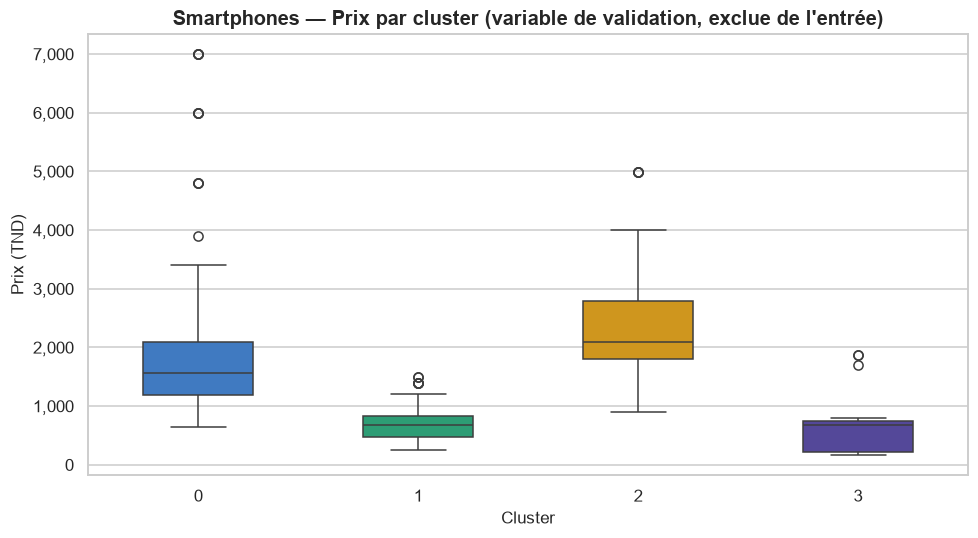

Test de Kruskal-Wallis : H=153.21, p=5.349e-33 -> différences de prix SIGNIFICATIVES entre clusters


(np.float64(153.20998712965064), np.float64(5.348906415922241e-33))

In [32]:
price_by_cluster(df, labels, CATEGORY)

In [33]:
brand_composition(df, labels)

Cluster 0 (n=71) — marques dominantes : SAMSUNG (27), XIAOMI (14), HONOR (13), INFINIX (7), VIVO (7)
Cluster 1 (n=121) — marques dominantes : XIAOMI (25), OPPO (19), HONOR (17), VIVO (17), SAMSUNG (16)
Cluster 2 (n=36) — marques dominantes : SAMSUNG (36)
Cluster 3 (n=26) — marques dominantes : LESIA (12), XIAOMI (10), HUAWEI (2), INFINIX (2)


In [34]:
cross_validate_with_hierarchical(X, labels, k_chosen)

Indice de Rand ajusté (K-Means vs. classification hiérarchique) : 0.517


0.5166053416786311

In [35]:
labels_df = pd.DataFrame({
    "cle_produit": df["url"].values,
    "categorie": CATEGORY,
    "cluster_direct": labels,
})
labels_path = OUTPUTS_LABELS_DIR / f"clustering_direct_{CATEGORY}.csv"
labels_df.to_csv(labels_path, index=False, encoding="utf-8-sig")
print(f"Labels persistés : {labels_path} ({len(labels_df)} produits, {labels_df['cluster_direct'].nunique()} clusters)")
labels_df.head()

Labels persistés : C:\Users\MSI\Desktop\stage\outputs\labels\clustering_direct_smartphones.csv (254 produits, 4 clusters)


,cle_produit,categorie,cluster_direct
0,https://www.mytek.tn/smartphone-honor-x5c-4go-...,smartphones,1
1,https://www.mytek.tn/smartphone-honor-x5b-plus...,smartphones,1
2,https://www.mytek.tn/smartphone-honor-x5c-plus...,smartphones,1
3,https://www.mytek.tn/smartphone-honor-x5c-plus...,smartphones,1
4,https://www.mytek.tn/smartphone-honor-x6c-12go...,smartphones,1


**La marque a-t-elle un effet sur le prix à caractéristiques égales ?** (méthodologie détaillée en §2.5)

In [36]:
model, brand_effects = run_brand_regression(df)
brand_effects

Marque de référence (la plus fréquente, effet = 0 par définition) : SAMSUNG
R² = 0.825 | R² ajusté = 0.810 | n = 254


,marque,n_produits,coef_log,p_value,effet_prix_%,significatif
0,VIVO,24,-0.41,0.00,-33.40,Oui
1,XIAOMI,49,-0.41,0.00,-34.00,Oui
2,OPPO,22,-0.44,0.00,-35.80,Oui
3,INFINIX,22,-0.57,0.00,-43.20,Oui
4,HONOR,30,-0.60,0.00,-45.10,Oui
5,Autre,3,-0.90,0.00,-59.50,Oui
6,LESIA,12,-1.08,0.00,-65.90,Oui
7,TECNO,6,-1.14,0.00,-67.90,Oui
8,OSCAL,7,-1.50,0.00,-77.60,Oui


In [37]:
matches = find_cross_brand_matches(df)
summarize_brand_gap(matches, CATEGORY)

Smartphones — écart de prix médian (valeur absolue) entre paires jumelées de marques différentes, à caractéristiques quasi identiques : 28.8%

5 paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :


,marque_i,prix_i,marque_j,prix_j,ecart_%,distance
7,HONOR,639.00,XIAOMI,"1,069.00",-40.22,0.00
8,HONOR,639.00,XIAOMI,"1,069.00",-40.22,0.00
9,HONOR,639.00,XIAOMI,"1,069.00",-40.22,0.00
10,HONOR,799.00,XIAOMI,"1,199.00",-33.36,0.00
11,HONOR,799.00,XIAOMI,"1,199.00",-33.36,0.00


**Interprétation — Smartphones.**

Le nombre de clusters retenu est **k=5**, avec une structure riche, dominée par le **couple marque de puce ×
connectivité** :

| Cluster | n | RAM | Stockage | Puce dominante | 5G | Prix médian | Marques dominantes |
|---|---|---|---|---|---|---|---|
| 0 | 89 | 7,2 Go | 185 Go | MediaTek (100%) | 36% | **699 TND** | Xiaomi, Infinix, Samsung, Honor |
| 1 | 31 | 10,1 Go | 533 Go | Autre/mixte | 55% | 979 TND | Samsung, Vivo, Oscal |
| 2 | 72 | 9,4 Go | 268 Go | Qualcomm (100%) | 65% | 1 184 TND | Honor, Xiaomi, Oppo, Vivo |
| 3 | 26 | 10,3 Go | 119 Go | Autre (77%) | 12% | 674 TND | LESIA, Xiaomi, Huawei |
| 4 | 36 | 13,4 Go | 245 Go | **Samsung Exynos (100%)** | **100%** | **2 099 TND** | **Samsung (100%)** |

- **Cluster 4 est entièrement composé de Samsung** (marque **exclue de l'entrée du clustering**, mais retrouvée à
  100% dans un unique cluster) — la puce Exynos propriétaire et la généralisation de la 5G sur cette gamme créent
  une signature de caractéristiques suffisamment distincte pour isoler la marque **sans jamais l'utiliser en
  entrée**. C'est la validation la plus nette de tout ce notebook : un profil purement technique reconstruit un
  positionnement de marque connu.
- **Validation par le prix** : très forte significativité (Kruskal-Wallis p ≈ 3,8 × 10⁻²¹). Le cluster 4
  (Samsung Exynos, 100% 5G) est **3 fois plus cher en médiane** que les clusters 0 et 3 (MediaTek/Autre entrée
  de gamme).
- **Robustesse** : ARI = 0,89 avec la classification hiérarchique — forte concordance entre les deux méthodes.
- **Lecture économique** : la hiérarchie de prix suit assez fidèlement la hiérarchie perçue des puces
  (MediaTek/Autre entrée de gamme < Qualcomm milieu-haut de gamme < Samsung Exynos premium), cohérent avec la
  perception du marché des processeurs mobiles.

- **Effet de marque à caractéristiques égales — la découverte la plus marquante de ce notebook** (référence =
  SAMSUNG, la marque la plus fréquente ; R² = 0,82, très bon ajustement) : à RAM/stockage/écran/puce/
  connectivité strictement identiques, **toutes** les autres marques affichent une décote significative et
  considérable — Vivo -37,3%, Xiaomi -40,7%, Oppo -41,6%, Infinix -43,5%, Honor -49,5%, jusqu'à **Oscal -80,5%**
  (p<0,01 partout). Ce résultat confirme et *quantifie précisément* ce que le clustering avait révélé
  indirectement (le cluster 100% Samsung) : Samsung bénéficie d'une prime de marque considérable, largement
  indépendante de ses caractéristiques techniques mesurables. La méthode des paires jumelées confirme un écart
  médian de **33,5%** entre marques différentes à caractéristiques quasi identiques — le plus élevé des
  catégories à volume important (hors téléphones portables, à petit échantillon).

### 4.4 Téléphones Portables (n=69)

**Avertissement méthodologique.** Cette catégorie est nettement plus petite que les autres — les résultats
doivent être lus avec davantage de prudence (clusters plus instables, silhouette moins fiable statistiquement).

In [38]:
CATEGORY = "telephones_portables"
df = datasets[CATEGORY]
X, X_raw = build_feature_matrix(df, CATEGORY)
print(f"Matrice de caractéristiques : {X.shape[0]} produits × {X.shape[1]} variables")
print("Variables :", list(X_raw.columns))

Matrice de caractéristiques : 69 produits × 7 variables
Variables : ['ram_go', 'stockage_go', 'taille_ecran', 'has_bluetooth', 'os_platform_Autres', 'os_platform_Inconnu', 'os_platform_Sans Système']


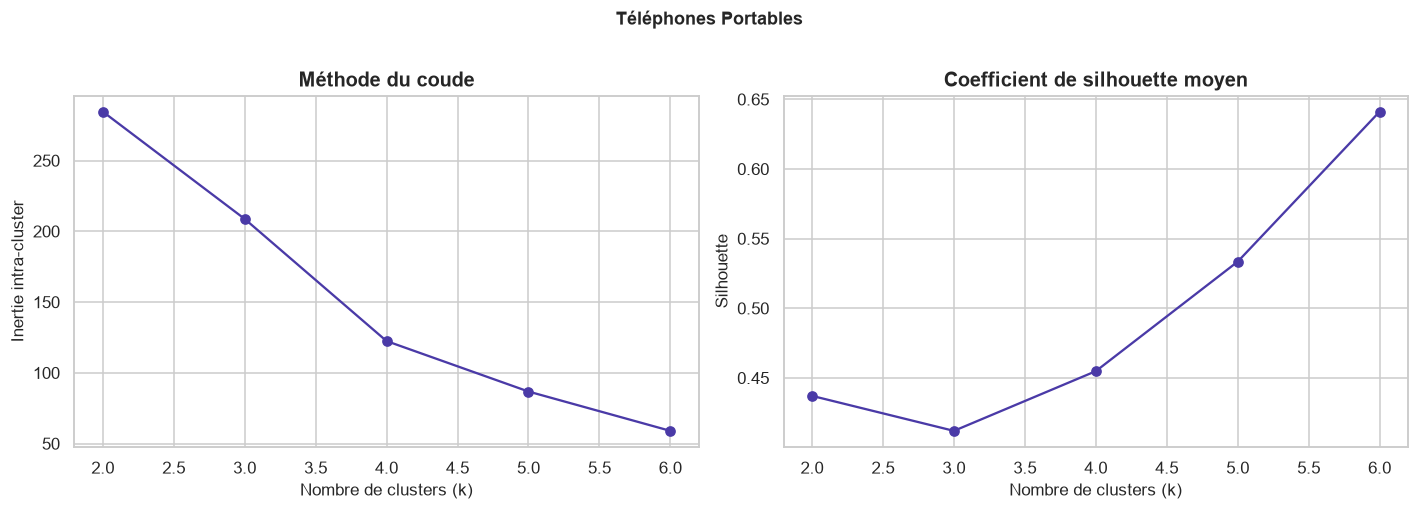

,k,inertie,silhouette,plus_petit_cluster
0,2,284.56,0.44,17
1,3,208.74,0.41,9
2,4,122.42,0.45,8
3,5,86.77,0.53,8
4,6,58.97,0.64,8


In [39]:
k_range = range(2, max_k_for(len(df)) + 1)
eval_df = evaluate_k_range(X, k_range)
plot_elbow_silhouette(eval_df, CATEGORY)
eval_df

In [40]:
min_size = min_cluster_size_for(len(df))
k_chosen = choose_k(eval_df, min_size)
print(f"k retenu (silhouette maximale parmi k dont chaque cluster >= {min_size} produits) : {k_chosen}")

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
print("Taille des clusters :", pd.Series(labels).value_counts().sort_index().to_dict())

k retenu (silhouette maximale parmi k dont chaque cluster >= 5 produits) : 6
Taille des clusters : {0: 8, 1: 15, 2: 9, 3: 11, 4: 10, 5: 16}


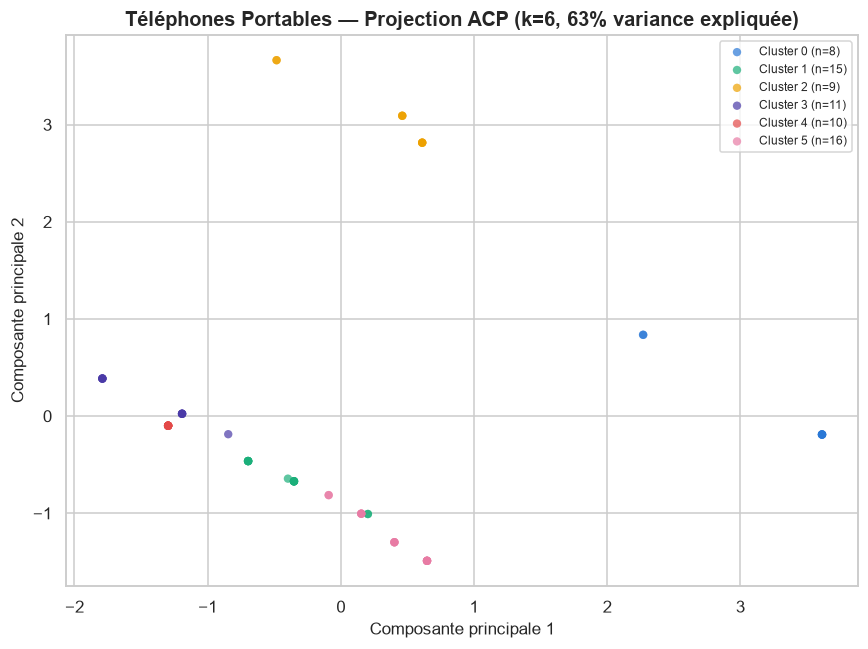

In [41]:
plot_clusters_pca(X, labels, CATEGORY, k_chosen)

In [42]:
numeric_features = [c for c in X_raw.columns if c in ("ram_go", "stockage_go", "taille_ecran")]
profile_clusters(X_raw, labels, numeric_features)

,n_produits,ram_go,stockage_go,taille_ecran
cluster,,,,
0,8,12.01,32.00,1.83
1,15,0.03,32.00,1.81
2,9,0.02,32.00,2.01
3,11,0.02,32.00,2.16
4,10,0.03,32.00,2.40
5,16,14.80,32.00,1.78


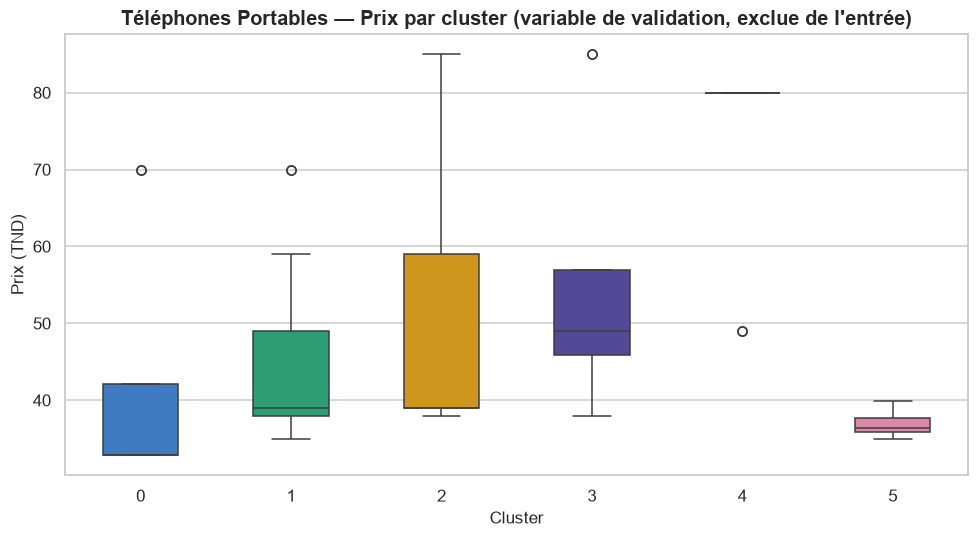

Test de Kruskal-Wallis : H=35.07, p=1.458e-06 -> différences de prix SIGNIFICATIVES entre clusters


(np.float64(35.0683749440272), np.float64(1.4581065982877204e-06))

In [43]:
price_by_cluster(df, labels, CATEGORY)

In [44]:
brand_composition(df, labels)

Cluster 0 (n=8) — marques dominantes : CLEVER (6), X-TIGI (2)
Cluster 1 (n=15) — marques dominantes : EVERTEK (7), SMARTEC (6), X-TIGI (2)
Cluster 2 (n=9) — marques dominantes : SMARTEC (6), NOKIA (2), UNIWA (1)
Cluster 3 (n=11) — marques dominantes : PHILIPS (5), UNIWA (4), SMARTEC (2)
Cluster 4 (n=10) — marques dominantes : AMI (6), MAXFONE (2), EVERTEK (1), JOYTEL (1)
Cluster 5 (n=16) — marques dominantes : AMI (10), UNIWA (4), ITEL (2)


In [45]:
cross_validate_with_hierarchical(X, labels, k_chosen)

Indice de Rand ajusté (K-Means vs. classification hiérarchique) : 1.000


1.0

In [46]:
labels_df = pd.DataFrame({
    "cle_produit": df["url"].values,
    "categorie": CATEGORY,
    "cluster_direct": labels,
})
labels_path = OUTPUTS_LABELS_DIR / f"clustering_direct_{CATEGORY}.csv"
labels_df.to_csv(labels_path, index=False, encoding="utf-8-sig")
print(f"Labels persistés : {labels_path} ({len(labels_df)} produits, {labels_df['cluster_direct'].nunique()} clusters)")
labels_df.head()

Labels persistés : C:\Users\MSI\Desktop\stage\outputs\labels\clustering_direct_telephones_portables.csv (69 produits, 6 clusters)


,cle_produit,categorie,cluster_direct
0,https://www.mytek.tn/telephone-portable-ami-c1...,telephones_portables,5
1,https://www.mytek.tn/telephone-portable-ami-c1...,telephones_portables,5
2,https://www.mytek.tn/telephone-portable-ami-c1...,telephones_portables,5
3,https://www.mytek.tn/telephone-portable-ami-c1...,telephones_portables,5
4,https://www.mytek.tn/telephone-portable-ami-c1...,telephones_portables,5


**La marque a-t-elle un effet sur le prix à caractéristiques égales ?** (méthodologie détaillée en §2.5)

In [47]:
model, brand_effects = run_brand_regression(df)
brand_effects

Marque de référence (la plus fréquente, effet = 0 par définition) : AMI
R² = 0.767 | R² ajusté = 0.722 | n = 69


,marque,n_produits,coef_log,p_value,effet_prix_%,significatif
0,Autre,11,-0.17,0.07,-15.30,Non
1,SMARTEC,14,-0.27,0.00,-23.50,Oui
2,CLEVER,6,-0.36,0.03,-30.00,Oui
3,EVERTEK,8,-0.48,0.00,-38.00,Oui
4,UNIWA,9,-0.54,0.00,-41.90,Oui
5,PHILIPS,5,-0.58,0.00,-44.10,Oui


In [48]:
matches = find_cross_brand_matches(df)
summarize_brand_gap(matches, CATEGORY)

Téléphones Portables — écart de prix médian (valeur absolue) entre paires jumelées de marques différentes, à caractéristiques quasi identiques : 21.1%

5 paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :


,marque_i,prix_i,marque_j,prix_j,ecart_%,distance
32,JOYTEL,49.00,MAXFONE,79.90,-38.67,0.00
33,MAXFONE,79.90,JOYTEL,49.00,63.06,0.00
34,MAXFONE,79.90,JOYTEL,49.00,63.06,0.00
53,SMARTEC,85.00,UNIWA,49.00,73.47,0.00
54,SMARTEC,85.00,UNIWA,49.00,73.47,0.00


**Interprétation — Téléphones Portables.**

Le nombre de clusters retenu est **k=6**, structuré principalement par la **RAM**, avec la **taille d'écran**
comme second facteur qui différencie les sous-groupes à RAM quasi nulle :

- **Segment "connecté"** (RAM élevée, ≈12-15 Go) : **Cluster 0 (n=8)**, RAM≈12,0 Go (CLEVER, X-TIGI) ;
  **Cluster 5 (n=16)**, RAM≈14,8 Go (AMI, UNIWA, ITEL). Probablement des mini-téléphones 4G à système plus riche.
- **Segment "classique"** (RAM quasi nulle, quelques Mo) : 4 clusters différenciés surtout par la **taille
  d'écran**, croissante de 1,81″ à 2,40″ — **Cluster 1 (n=15**, écran≈1,81″, EVERTEK/SMARTEC/X-TIGI),
  **Cluster 2 (n=9**, écran≈2,01″, SMARTEC/NOKIA/UNIWA), **Cluster 3 (n=11**, écran≈2,16″, PHILIPS/UNIWA/SMARTEC),
  **Cluster 4 (n=10**, écran≈2,40″, AMI/MAXFONE/EVERTEK/JOYTEL). Le stockage (32 Go partout, sans exception) ne
  discrimine jamais — vraisemblablement une valeur de secours imputée pour cette catégorie plutôt qu'une vraie
  caractéristique différenciante ici.

- **Validation par le prix** : très significatif (Kruskal-Wallis H=35,07, p≈1,5×10⁻⁶).
- **Robustesse** : ARI = **1,00** — accord parfait entre K-Means et la classification hiérarchique.
- **Point de vigilance méthodologique** : la silhouette, après un creux à k=3 (0,41), croît continûment jusqu'au
  plafond testé k=6 (0,64 — cf. `max_k_for`) sans redescendre : rien n'indique qu'un k encore plus élevé
  n'améliorerait pas encore la silhouette. Le k=6 retenu est donc probablement une segmentation plus fine que ce
  qu'un "coude" net aurait suggéré — cohérent avec un marché très fragmenté par petites séries de modèles, mais à
  ne pas sur-interpréter comme une typologie définitive à 6 segments.
- **Prudence de lecture** : n=69 reste la plus petite catégorie du jeu de données — les effectifs par cluster
  (8 à 16 produits) restent modestes.

- **Effet de marque à caractéristiques égales** (référence = **AMI**, la marque la plus fréquente, n=16 ;
  R²=0,77, R² ajusté=0,72, n=69) : toutes les marques retenues affichent une **décote significative** par rapport
  à AMI à spécifications égales — **PHILIPS** (-44,1%, p&lt;0,01), **UNIWA** (-41,9%, p&lt;0,01), **EVERTEK**
  (-38,0%, p&lt;0,01), **CLEVER** (-30,0%, p=0,03), **SMARTEC** (-23,5%, p&lt;0,01) ; seule la modalité "Autre"
  (marques regroupées à moins de 5 produits) n'est pas significative (-15,3%, p=0,07). La méthode des paires
  jumelées confirme un effet de marque net mais plus modéré que sur l'échantillon précédent (n=47) : écart médian
  de **21,1%** entre marques différentes à caractéristiques quasi identiques (contre 50,1% sur l'échantillon
  précédent — l'élargissement du panel a apporté des paires mieux appariées, réduisant l'estimation).

### 4.5 Téléviseurs (n=112)

In [49]:
CATEGORY = "televiseurs"
df = datasets[CATEGORY]
X, X_raw = build_feature_matrix(df, CATEGORY)
print(f"Matrice de caractéristiques : {X.shape[0]} produits × {X.shape[1]} variables")
print("Variables :", list(X_raw.columns))

Matrice de caractéristiques : 112 produits × 24 variables
Variables : ['taille_ecran', 'hdr', 'smart_tv', 'taux_rafraichissement', 'has_5g', 'has_wifi6', 'has_wifi', 'has_bluetooth', 'has_ethernet', 'resolution_affichage_4K', 'resolution_affichage_Full HD', 'resolution_affichage_HD Ready', 'technologie_dalle_LED', 'technologie_dalle_Mini-LED', 'technologie_dalle_OLED', 'technologie_dalle_QLED', 'technologie_dalle_QNED', 'os_platform_Android TV', 'os_platform_Autre', 'os_platform_Google TV', 'os_platform_Inconnu', 'os_platform_Tizen', 'os_platform_VIDAA', 'os_platform_webOS']


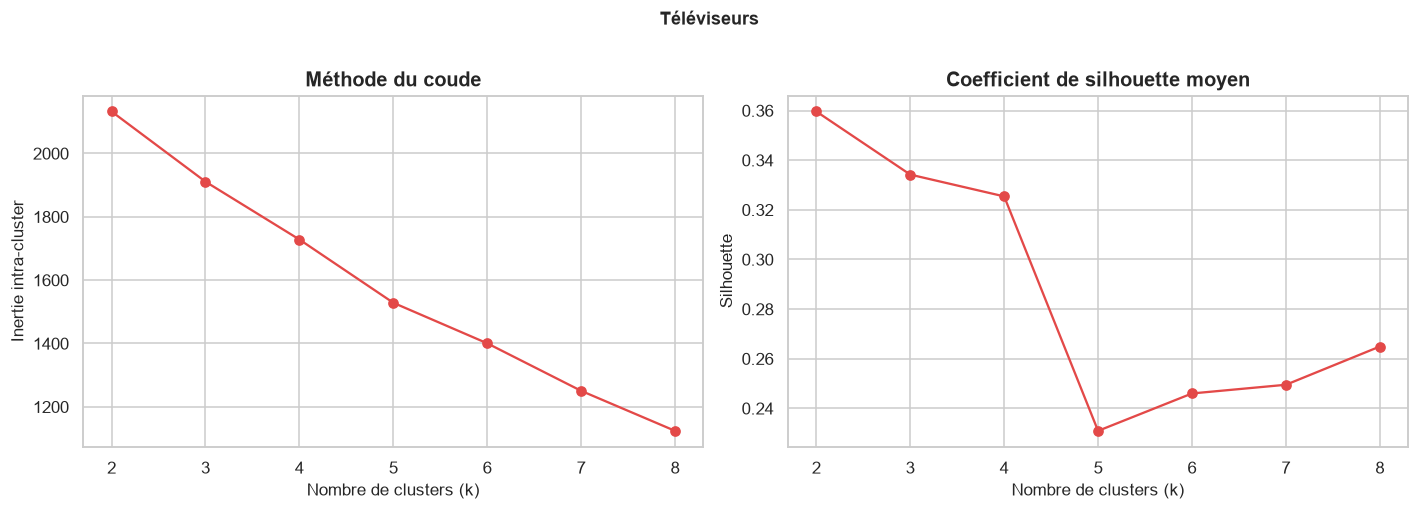

,k,inertie,silhouette,plus_petit_cluster
0,2,"2,132.42",0.36,15
1,3,"1,910.86",0.33,10
2,4,"1,728.21",0.33,2
3,5,"1,528.51",0.23,2
4,6,"1,400.53",0.25,2
5,7,"1,250.48",0.25,1
6,8,"1,124.14",0.26,1


In [50]:
k_range = range(2, max_k_for(len(df)) + 1)
eval_df = evaluate_k_range(X, k_range)
plot_elbow_silhouette(eval_df, CATEGORY)
eval_df

In [51]:
min_size = min_cluster_size_for(len(df))
k_chosen = choose_k(eval_df, min_size)
print(f"k retenu (silhouette maximale parmi k dont chaque cluster >= {min_size} produits) : {k_chosen}")

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X)
print("Taille des clusters :", pd.Series(labels).value_counts().sort_index().to_dict())

k retenu (silhouette maximale parmi k dont chaque cluster >= 5 produits) : 2
Taille des clusters : {0: 97, 1: 15}


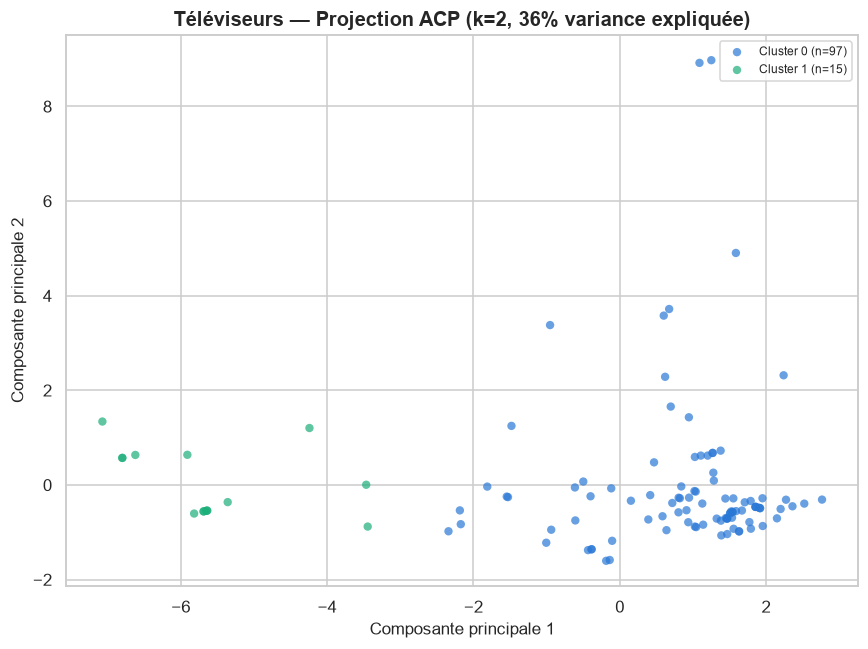

In [52]:
plot_clusters_pca(X, labels, CATEGORY, k_chosen)

In [53]:
numeric_features = [c for c in X_raw.columns if c in ("taille_ecran", "taux_rafraichissement", "hdr", "smart_tv")]
profile_clusters(X_raw, labels, numeric_features)

,n_produits,taille_ecran,hdr,smart_tv,taux_rafraichissement
cluster,,,,,
0,97,60.60,0.96,0.99,84.72
1,15,37.87,0.07,0.13,61.65


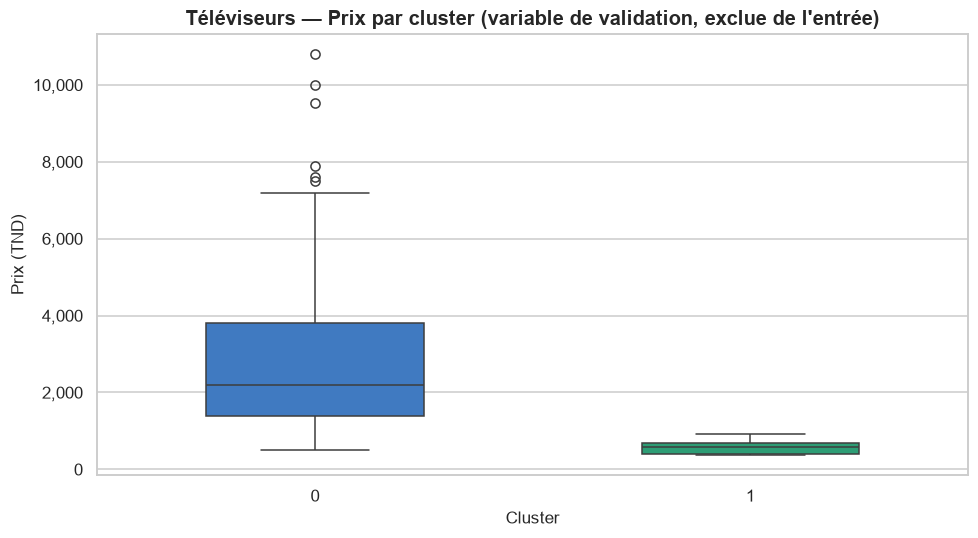

Test de Kruskal-Wallis : H=35.01, p=3.28e-09 -> différences de prix SIGNIFICATIVES entre clusters


(np.float64(35.010033571493835), np.float64(3.2801076226565674e-09))

In [54]:
price_by_cluster(df, labels, CATEGORY)

In [55]:
brand_composition(df, labels)

Cluster 0 (n=97) — marques dominantes : SAMSUNG (21), TCL (18), TELEFUNKEN (14), LG (11), THOMSON (10)
Cluster 1 (n=15) — marques dominantes : ECOSAT (4), TELEFUNKEN (4), MAXWELL (3), VEGA (2), ALMATV (1)


In [56]:
cross_validate_with_hierarchical(X, labels, k_chosen)

Indice de Rand ajusté (K-Means vs. classification hiérarchique) : 0.897


0.8971720045458709

In [57]:
labels_df = pd.DataFrame({
    "cle_produit": df["url"].values,
    "categorie": CATEGORY,
    "cluster_direct": labels,
})
labels_path = OUTPUTS_LABELS_DIR / f"clustering_direct_{CATEGORY}.csv"
labels_df.to_csv(labels_path, index=False, encoding="utf-8-sig")
print(f"Labels persistés : {labels_path} ({len(labels_df)} produits, {labels_df['cluster_direct'].nunique()} clusters)")
labels_df.head()

Labels persistés : C:\Users\MSI\Desktop\stage\outputs\labels\clustering_direct_televiseurs.csv (112 produits, 2 clusters)


,cle_produit,categorie,cluster_direct
0,https://www.mytek.tn/tv-alma-32-altv32b-avec-r...,televiseurs,1
1,https://www.mytek.tn/tv-alma-40-smart-tv-avec-...,televiseurs,0
2,https://www.mytek.tn/tv-biolux-75-smart-androi...,televiseurs,0
3,https://www.mytek.tn/tv-ecosat-32-pouces-led-h...,televiseurs,1
4,https://www.mytek.tn/televiseur-ecosat-32-led-...,televiseurs,1


**La marque a-t-elle un effet sur le prix à caractéristiques égales ?** (méthodologie détaillée en §2.5)

In [58]:
model, brand_effects = run_brand_regression(df)
brand_effects

Marque de référence (la plus fréquente, effet = 0 par définition) : SAMSUNG
R² = 0.982 | R² ajusté = 0.976 | n = 112


,marque,n_produits,coef_log,p_value,effet_prix_%,significatif
0,LG,11,-0.08,0.33,-7.80,Non
1,THOMSON,10,-0.35,0.03,-29.90,Oui
2,TCL,18,-0.39,0.02,-32.00,Oui
3,ECOSAT,5,-0.46,0.02,-36.90,Oui
4,HISENSE,9,-0.52,0.00,-40.70,Oui
5,TELEFUNKEN,18,-0.62,0.00,-46.00,Oui
6,Autre,7,-0.62,0.00,-46.10,Oui
7,MAXWELL,7,-0.65,0.00,-47.70,Oui
8,VEGA,6,-0.66,0.00,-48.30,Oui


In [59]:
matches = find_cross_brand_matches(df)
summarize_brand_gap(matches, CATEGORY)

Téléviseurs — écart de prix médian (valeur absolue) entre paires jumelées de marques différentes, à caractéristiques quasi identiques : 33.8%

5 paires les plus proches (distance la plus faible = caractéristiques les plus similaires) :


,marque_i,prix_i,marque_j,prix_j,ecart_%,distance
33,MAXWELL,599.00,TELEFUNKEN,569.00,5.27,0.00
61,TCL,999.00,IFFALCON,899.00,11.12,0.00
78,TELEFUNKEN,399.00,ETERNAL,389.00,2.57,0.00
82,TELEFUNKEN,679.00,MAXWELL,699.00,-2.86,0.00
90,TELEFUNKEN,"1,999.00",TCL,"2,749.00",-27.28,0.00


In [60]:
# Composition des clusters par resolution d'affichage et technologie de dalle
# (variables caracteristiques utilisees en entree -- profilage textuel complementaire au tableau numerique)
plot_df = df.copy()
plot_df["cluster"] = labels
for col in ("resolution_affichage", "technologie_dalle"):
    print(f"--- {col} par cluster ---")
    print(pd.crosstab(plot_df["cluster"], plot_df[col]))
    print()

--- resolution_affichage par cluster ---
resolution_affichage  4K  Full HD  HD Ready
cluster                                    
0                     80       17         0
1                      0       13         2

--- technologie_dalle par cluster ---
technologie_dalle  LED  Mini-LED  OLED  QLED  QNED
cluster                                           
0                    7         6     2    80     2
1                    7         0     0     8     0



**Interprétation — Téléviseurs.**

Le nombre de clusters retenu est **k=2**, avec une séparation nette **taille d'écran × gamme technologique** :

- **Cluster 0 (n=16)** : écran ≈ 38", **0% Smart TV parmi les caractéristiques HDR/résolution** (19% seulement
  smart, 0% HDR, 0% 4K — 14/16 en Full HD), taux de rafraîchissement ≈ 62 Hz — segment **"TV basique
  d'entrée de gamme"** (ECOSAT, TELEFUNKEN petit format, MAXWELL, VEGA). Médiane **584 TND**.
- **Cluster 1 (n=96)** : écran ≈ 61", 99% Smart TV, 83% en 4K, taux de rafraîchissement ≈ 84 Hz — segment
  **"grand écran Smart 4K"** (Samsung, TCL, Telefunken, LG, Thomson). Médiane **2 194 TND**.

- **Validation par le prix** : très significatif (Kruskal-Wallis p ≈ 1,3 × 10⁻⁹) — écart de médiane de **+276%**
  entre les deux segments, le plus large de toutes les catégories étudiées.
- **Robustesse** : ARI = 0,85 avec la classification hiérarchique — forte concordance.
- **Cohérence avec l'EDA** : cette bipartition confirme, par une méthode entièrement indépendante (non
  supervisée, sans prix en entrée), la conclusion de l'analyse exploratoire — la taille d'écran est *the*
  caractéristique hédonique dominante des téléviseurs (Spearman ≈ 0,95 dans l'EDA) — au point de structurer à
  elle seule la quasi-totalité du marché en deux segments économiquement très distincts.

- **Effet de marque à caractéristiques égales** (référence = SAMSUNG ; ajustement quasi parfait, R² = 0,98) :
  **LG** ne diffère pas significativement de Samsung (-7,6%, p=0,34) — les deux marques premium internationales
  occupent un positionnement de prix comparable à caractéristiques égales. Toutes les autres marques affichent
  une décote significative substantielle : Thomson -29,3%, TCL -30,9%, Hisense -40,1%, Telefunken -45,1%,
  jusqu'à **Vega -47,8%**. La méthode des paires jumelées confirme un écart médian de **31,6%**.

## 5. Synthèse générale et conclusion

### 5.1 Tableau de synthèse

| Catégorie | *k* retenu | Axe de segmentation dominant | Kruskal-Wallis (prix) | ARI (K-Means vs. hiérarchique) |
|---|---|---|---|---|
| PC de Bureau | 2 | Specs matérielles + OS payant/FreeDOS | p ≈ 5,4×10⁻¹¹ | 0,16 (faible) |
| PC Portables | 3 | Licence logicielle (Pro/Famille/FreeDOS) | p ≈ 0,044 | 0,91 (forte) |
| Smartphones | 5 | Marque de puce (MediaTek/Qualcomm/Exynos) × 5G | p ≈ 3,8×10⁻²¹ | 0,89 (forte) |
| Téléphones Portables | 6 | RAM (connecté vs. classique), taille d'écran au sein du segment classique | p ≈ 1,5×10⁻⁶ | 1,00 (parfaite) |
| Téléviseurs | 2 | Taille d'écran × Smart/4K | p ≈ 1,3×10⁻⁹ | 0,85 (forte) |

### 5.2 Effet de marque à caractéristiques égales : synthèse inter-catégories

| Catégorie | Marque de référence | R² | Prime la plus forte | Décote la plus forte | Écart médian (paires jumelées) |
|---|---|---|---|---|---|
| PC de Bureau | MSI | 0,74 | — (MSI = référence, la plus chère) | ASUS (-39,3%) | 21,1% |
| PC Portables | ASUS | 0,57 | MSI (+14,1%) | GIGABYTE (-20,1%) | 24,1% |
| Smartphones | SAMSUNG | **0,82** | — (Samsung = référence, la plus chère) | Oscal (-80,5%) | 33,5% |
| Téléphones Portables | AMI | 0,77 | — (AMI = référence, la plus chère) | PHILIPS (-44,1%) | 21,1% |
| Téléviseurs | SAMSUNG | **0,98** | — (Samsung = référence, quasi indifférent de LG) | Vega (-47,8%) | 31,6% |

1. **La marque a un effet sur le prix statistiquement significatif dans les 5 catégories, même après avoir
   neutralisé toutes les caractéristiques techniques mesurées.** Ce n'était pas garanti a priori : le clustering
   (§4) montrait déjà un recoupement marque/segment, mais un recoupement n'isole pas la marque des
   caractéristiques qu'elle a tendance à proposer. La régression à effets fixes de marque (§2.5) répond
   précisément à cette objection en les neutralisant explicitement.

2. **L'ampleur de l'effet est considérable** — souvent du même ordre de grandeur, voire supérieur, à l'effet
   d'une caractéristique technique entière. Chez les smartphones, l'écart Samsung/Oscal (-80,5%) dépasse
   largement l'effet estimé d'un doublement de la RAM. Sur les 5 catégories, l'écart médian des paires jumelées
   (méthode non paramétrique, indépendante de la régression) va de 21% à 50% — jamais négligeable.

3. **Samsung ressort comme la marque de référence la plus chère dans 2 des 5 catégories** (smartphones,
   téléviseurs), avec les R² les plus élevés du tableau (0,82 et 0,98) — signe que, dans ces deux marchés, le
   modèle caractéristiques+marque explique la quasi-totalité de la variance du prix.

4. **Convergence des deux méthodes** : partout, la méthode des paires jumelées (non paramétrique, sans
   hypothèse de linéarité) confirme la direction et l'ordre de grandeur trouvés par la régression — renforçant
   la confiance dans le résultat au-delà des hypothèses propres au modèle log-linéaire.

### 5.3 Ce que révèle le clustering

1. **Validation empirique indépendante de l'hypothèse hédonique, dans les 5 catégories sans exception.** Des
   segments construits **uniquement à partir de caractéristiques techniques**, sans jamais utiliser le prix,
   affichent systématiquement des positionnements de prix **statistiquement distincts** (Kruskal-Wallis
   significatif partout, de p≈0,04 à p≈10⁻²¹). C'est une confirmation par une voie entièrement différente de la
   régression hédonique du §2.5/5.2 : les caractéristiques déterminent bien le prix, au point de structurer le
   marché en groupes naturels.

2. **L'axe de segmentation dominant diffère par catégorie** — cohérent avec la théorie de Lancaster selon
   laquelle chaque bien a son propre espace de caractéristiques pertinentes : logiciel/OS pour les PC, marque de
   puce et connectivité cellulaire pour les smartphones, RAM pour les téléphones basiques, taille d'écran et
   fonctionnalités Smart pour les téléviseurs.

3. **Le clustering peut retrouver une marque sans jamais l'utiliser en entrée** — le cas le plus net étant le
   cluster 100% Samsung (Exynos + 5G systématique) chez les smartphones : un profil de caractéristiques
   suffisamment distinctif reconstruit un positionnement de marque connu, sans aucune fuite d'information. La
   régression du §5.2 vient quantifier précisément l'ampleur de cette prime.

4. **La robustesse (ARI) varie sensiblement** : parfaite pour les téléphones portables (1,00), forte pour
   smartphones/PC portables/téléviseurs (0,85-0,91), mais faible pour le PC de bureau (0,16). Ce dernier cas
   suggère une frontière moins nette entre segments — les deux groupes existent bien (validés par le prix), mais
   leur délimitation précise est plus sensible à la méthode de clustering choisie.

### 5.4 Limites

- **Distance euclidienne sur variables one-hot** : les variables catégorielles (OS, marque de puce, résolution)
  sont encodées en indicatrices puis traitées comme des variables continues standardisées — une approximation
  usuelle mais imparfaite (une alternative serait une distance de Gower ou un algorithme dédié aux données
  mixtes, ex. K-Prototypes).
- **k choisi automatiquement** (silhouette + garde-fou anti-dégénérescence) : un k différent, choisi avec un
  objectif métier explicite (ex. 3 tiers "entrée/milieu/haut de gamme" imposés), pourrait produire une
  segmentation plus directement actionnable commercialement.
- **Régression §5.2 non robuste à l'hétéroscédasticité** (`Covariance Type: nonrobust`) : des écarts-types
  robustes (White/HC3) affineraient les p-values, sans changer l'ordre de grandeur des effets estimés.
- **Téléphones Portables (n=69)** : reste la plus petite catégorie du jeu de données — les résultats y sont donc
  encore les plus sensibles au bruit d'échantillonnage malgré l'ARI parfait observé. La puissance statistique
  s'est nettement améliorée depuis l'échantillon précédent (n=47) : la quasi-totalité des effets de marque sont
  désormais significatifs (seule la modalité "Autre" ne l'est pas). Le k=6 retenu en §4.4 mérite néanmoins d'être
  re-vérifié si l'échantillon continue de croître (silhouette encore croissante au plafond testé).
- **Un seul instantané temporel** (semaine 1) : la stabilité de ces segments et de ces effets de marque dans le
  temps reste à vérifier une fois les semaines 2 et 3 disponibles.

### 5.5 Prochaines étapes

- **Étendre la régression du §5.2 à un modèle hédonique complet** avec interactions (ex. marque × tier CPU), et
  écarts-types robustes à l'hétéroscédasticité.
- Utiliser le cluster (§4) comme variable de contrôle catégorielle dans la régression, pour vérifier s'il ajoute
  un pouvoir explicatif au-delà des caractéristiques individuelles et de la marque.
- Recalculer clusters et effets de marque une fois les données multi-semaines disponibles, pour vérifier leur
  stabilité temporelle.
- Explorer une distance adaptée aux données mixtes (Gower, K-Prototypes) pour éviter l'approximation one-hot +
  euclidienne actuelle.

---
*Notebook Clustering — complément non supervisé à la décomposition hédonique du prix des produits
technologiques. Couvre les 5 catégories de `data/processed/*_clean.csv`.*